#  - Greenfield Fischer Tropsch Südafrika -

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof import solph
from oemof.tools import economics
import matplotlib.dates as mdates


# Farbeinstellungen

In [2]:
# Sektoren: col_el, col_chem, col_h2, col_co2, col_saf, col_q
# Technologien: col_pem, col_pv, col_dac, col_ft, col_wka, col_h2s, col_bat, col_hp
# Bilanz: col_sell, col_buy
# Sonstige: col_etc

col_co2 = col_dac = "#050505"               # Diesel grau
col_pv = "#e4cb3a"                          # PV Gelb
col_wka = "#128fcf"                         # WKA Blau
col_h2 = col_pem = "#14689b"                # Corporate Blau                oder Wasser blau: "#1b5aa6"
col_saf = col_ft = "#c796c4"                # Coorporate lila blass                
col_h2s = "#79CADD"                         # Coorporate Hellblau
col_bat = "#8CBF3E"                         # ElChem Speicher grün
col_buy = "#505050"
col_chem = "#1D9838"              # Biomasse Grün
col_etc = "#828282"                         # Corporate Grau
col_el= col_sell = "#E02229"                # Stromsektor Rot
col_q = col_hp = "#B01920"                  # Dunkelrot (Geothermie rot) 
col_qs = "#B96428"                          # Braunkohle braun
col_naph = "#DADADA"                        # Coorporate grau blass

# 1 Eingangsdaten

In [3]:
volllaststunden = pd.read_csv("Lastprofile.csv", sep=';', decimal=',')

Eingangsdaten_df = pd.read_excel("Datenbank.xlsx", sheet_name="Datenauswahl", decimal=',')
Eingangsdaten_df.set_index("Variable", inplace=True)   
Eingangsdaten = Eingangsdaten_df["Wert"].to_dict()

Ergebnisse_df = pd.read_excel("Datenbank.xlsx", sheet_name="Ergebnisse", decimal=',')
Ergebnisse_df.set_index("Variable", inplace=True)

#Anpassung der Zinssätze auf Südafrika 
aufschlag = 0.028 #Wert auf Basis von Damoran Länder Risiken

zinssatz_keys = [

"zinssatz_ft",
"zinssatz_dac",
"zinssatz_h2s",
"zinssatz_pem", 
"zinssatz_qs", 
"zinssatz_hp", 
"zinssatz_bat", 
"zinssatz_wkaon",
"zinssatz_pv",

]

Eingangsdaten_df.loc[zinssatz_keys, "Wert"] += aufschlag

Eingangsdaten = Eingangsdaten_df["Wert"].to_dict()


##  1.1 Darstellung Eingangsdaten

### 1.1.1 Profile

<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
C:\Users\hem38994\AppData\Local\Temp\ipykernel_28412\2384124232.py:39: SyntaxWarning: invalid escape sequence '\e'
  plt.savefig("Bilder\eingangsdaten_einspeise_lastprofile.png", dpi=300, bbox_inches='tight')


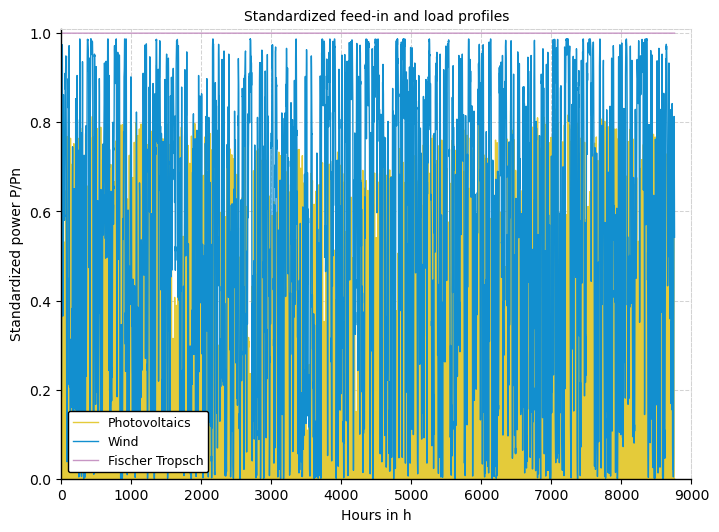

In [4]:
plt.figure(figsize=(7, 5))
plt.plot(volllaststunden['PV Südafrika'], label="Photovoltaics", color=col_pv, linewidth=1)
plt.plot(volllaststunden['Wind Südafrika'], label="Wind", color=col_wka, linewidth=1)
plt.plot(volllaststunden['Volllast'], label="Fischer Tropsch", color=col_ft, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(0, 1.01)
plt.xlim(0, 9000)

plt.title("Standardized feed-in and load profiles", fontsize=10)
plt.xlabel("Hours in h", fontsize=10)
plt.ylabel("Standardized power P/Pn", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='lower left', fontsize=9, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
plt.savefig("Bilder\eingangsdaten_einspeise_lastprofile.png", dpi=300, bbox_inches='tight')
plt.show()



### 1.1.2 CAPEX

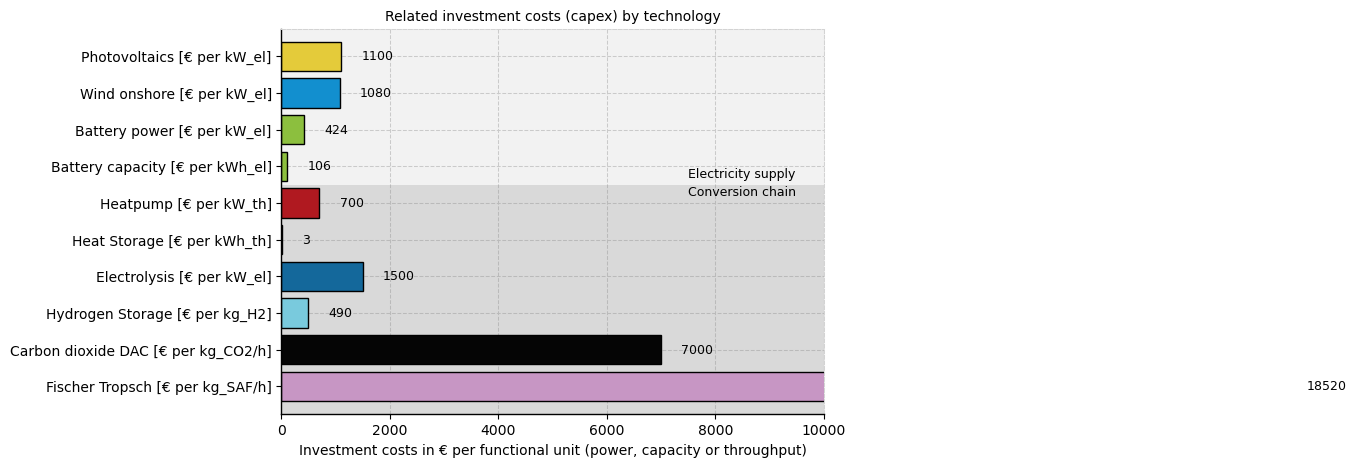

In [5]:
categories = [
    "Fischer Tropsch [€ per kg_SAF/h]", "Carbon dioxide DAC [€ per kg_CO2/h]", "Hydrogen Storage [€ per kg_H2]", "Electrolysis [€ per kW_el]", "Heat Storage [€ per kWh_th]" ,"Heatpump [€ per kW_th]",
    "Battery capacity [€ per kWh_el]", "Battery power [€ per kW_el]", "Wind onshore [€ per kW_el]", "Photovoltaics [€ per kW_el]"
]

values = [
    Eingangsdaten["capex_ft"], Eingangsdaten["capex_dac"], Eingangsdaten["capex_h2s"], Eingangsdaten["capex_pem"], Eingangsdaten["capex_qs"], Eingangsdaten["capex_hp"],
    Eingangsdaten["capex_bat_kapa"], Eingangsdaten["capex_bat_leistung"], Eingangsdaten["capex_wkaon"], Eingangsdaten["capex_pv"]
]

colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 5.5
ax.axhspan(cut, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(categories)-0.25])
ax.text(7500, cut+0.2, "Electricity supply", fontsize=9, color="black")  
ax.text(7500, cut-0.3, "Conversion chain", fontsize=9, color="black")

# boundary_y = 3.5  # Grenze zwischen "Conversion chain" und "Electricity supply"
# ax.plot([0, 10000], [boundary_y, boundary_y], color='black', linewidth=0.5, linestyle='--')

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:.0f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Investment costs in € per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related investment costs (capex) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 10000])

plt.savefig("Bilder/eingangsdaten_capex_bar.png", dpi=300, bbox_inches='tight')

### 1.1.3 OPEX

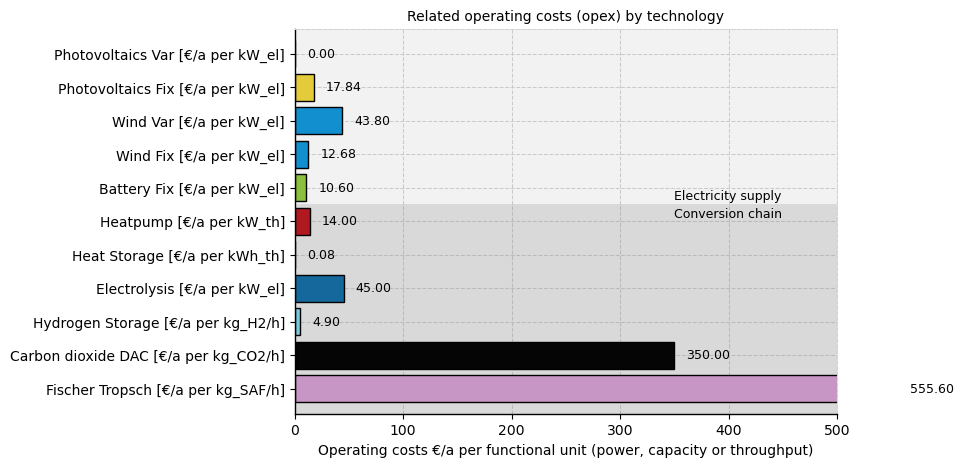

In [6]:
categories_opex = [
"Fischer Tropsch [€/a per kg_SAF/h]", "Carbon dioxide DAC [€/a per kg_CO2/h]", "Hydrogen Storage [€/a per kg_H2/h]", "Electrolysis [€/a per kW_el]", "Heat Storage [€/a per kWh_th]", "Heatpump [€/a per kW_th]",
"Battery Fix [€/a per kW_el]", "Wind Fix [€/a per kW_el]", "Wind Var [€/a per kW_el]",
"Photovoltaics Fix [€/a per kW_el]", "Photovoltaics Var [€/a per kW_el]"
]

values_opex = [
Eingangsdaten["opex_ft"] * Eingangsdaten["capex_ft"], # %/a * €/kg_CH3OH *h = €/a pro kg/h
Eingangsdaten["opex_dac"] * Eingangsdaten["capex_dac"], # %/a * €/kg_CO2 *h = €/a pro kg/h
Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"], # %/a * €/kg_H2 * h = €/a pro kg/h
Eingangsdaten["opex_pem"] * Eingangsdaten["capex_pem"], # %/a * €/kW_el = €/kWa
Eingangsdaten["opex_qs"] * Eingangsdaten["capex_qs"],   # %/a * €/kWh_th
Eingangsdaten["opex_hp"] * Eingangsdaten["capex_hp"], # %/a * €/kW_th = €/kW_th a
Eingangsdaten["opex_fix_bat"] * Eingangsdaten["capex_bat_leistung"], # %/a * €/kW_el = €/kWa
Eingangsdaten["opex_fix_wkaon"], # €/kWa
Eingangsdaten["opex_var_wkaon"] * 8760, # €/kWh *8760h/a = €/kWa
Eingangsdaten["opex_fix_pv"], # €/kWa
Eingangsdaten["opex_var_pv"] * 8760 # €/kWh *8760h/a = €/kWa
]

colors_opex = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_wka, col_wka, col_pv, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 12, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(categories_opex)-0.25])
ax.text(350, 5.65, "Electricity supply", fontsize=9, color="black")  
ax.text(350, 5.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories_opex, values_opex, color=colors_opex, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values_opex) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Operating costs €/a per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related operating costs (opex) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 500])

plt.savefig("Bilder/eingangsdaten_opex_bar.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1.4 Wirkungsgrade

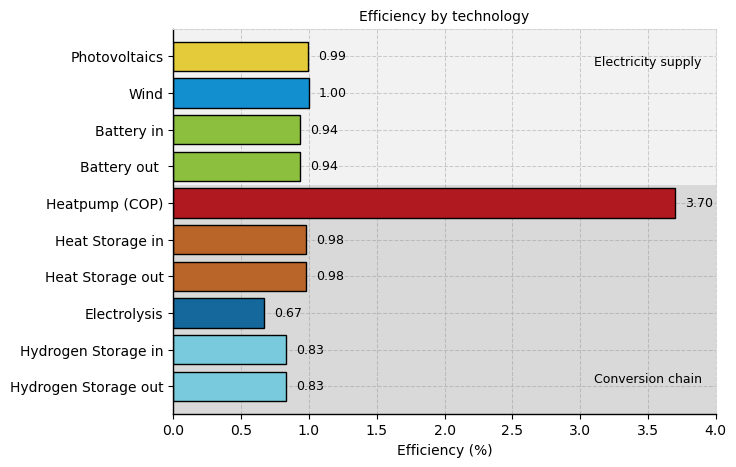

In [7]:
eta_params = ["Hydrogen Storage out", "Hydrogen Storage in","Electrolysis", "Heat Storage out", "Heat Storage in" ,"Heatpump (COP)", "Battery out ","Battery in", "Wind", "Photovoltaics"]
eta_values = [Eingangsdaten["eta_ausspeichern_h2s"],Eingangsdaten["eta_einspeichern_h2s"],Eingangsdaten["eta_pem"], Eingangsdaten["eta_ausspeichern_qs"], Eingangsdaten["eta_einspeichern_qs"], Eingangsdaten["eta_hp"], Eingangsdaten["eta_ausspeichern_bat"],Eingangsdaten["eta_einspeichern_bat"],Eingangsdaten["eta_wkaon"],Eingangsdaten["eta_pv"]]
eta_colors = [col_h2s,col_h2s,col_pem,col_qs, col_qs, col_hp, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(eta_values)-0.25])
ax.text(3.1, 8.75, "Electricity supply", fontsize=9, color="black")  
ax.text(3.1, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(eta_params, eta_values, color=eta_colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(eta_values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Efficiency (%)", fontsize=10)
plt.title("Efficiency by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 4])

plt.savefig("Bilder/eingangsdaten_eta_bar.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1.5 Zinssätze

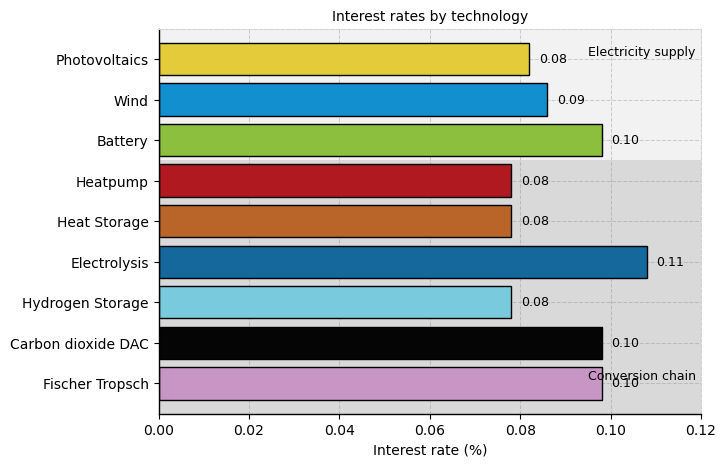

In [8]:
zins_params = ["Fischer Tropsch","Carbon dioxide DAC", "Hydrogen Storage","Electrolysis", "Heat Storage", "Heatpump", "Battery", "Wind", "Photovoltaics"]
zins_values = [Eingangsdaten["zinssatz_ft"],Eingangsdaten["zinssatz_dac"],Eingangsdaten["zinssatz_h2s"],Eingangsdaten["zinssatz_pem"], Eingangsdaten["zinssatz_qs"] , Eingangsdaten["zinssatz_hp"], Eingangsdaten["zinssatz_bat"], Eingangsdaten["zinssatz_wkaon"],Eingangsdaten["zinssatz_pv"]]
zins_colors = [col_ft,col_dac,col_h2s,col_pem, col_qs, col_hp, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(zins_values)-0.25])
ax.text(0.095, 8.1, "Electricity supply", fontsize=9, color="black")  
ax.text(0.095, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(zins_params, zins_values, color=zins_colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(zins_values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Interest rate (%)", fontsize=10)
plt.title("Interest rates by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 0.12])

plt.savefig("Bilder/eingangsdaten_zins_bar.png", dpi=300, bbox_inches='tight')



### 1.1.6 Lebensdauern

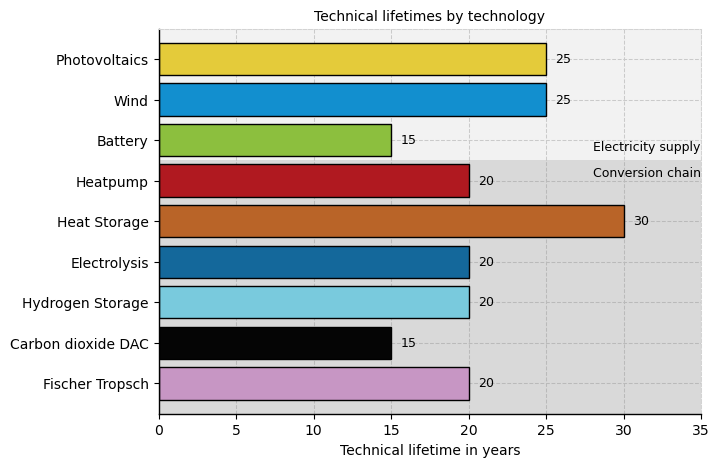

In [9]:
params = ["Fischer Tropsch","Carbon dioxide DAC", "Hydrogen Storage","Electrolysis","Heat Storage", "Heatpump","Battery", "Wind", "Photovoltaics"]
values = [Eingangsdaten["lebensdauer_ft"],Eingangsdaten["lebensdauer_dac"],Eingangsdaten["lebensdauer_h2s"],Eingangsdaten["lebensdauer_pem"], Eingangsdaten["lebensdauer_qs"], Eingangsdaten["lebensdauer_hp"],Eingangsdaten["lebensdauer_bat"], Eingangsdaten["lebensdauer_wkaon"],Eingangsdaten["lebensdauer_pv"]]
colors = [col_ft,col_dac,col_h2s,col_pem, col_qs, col_hp, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(28, 5.75, "Electricity supply", fontsize=9, color="black")  
ax.text(28, 5.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(params, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Technical lifetime in years", fontsize=10)
plt.title("Technical lifetimes by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 35])

plt.savefig("Bilder/eingangsdaten_lebensdauer_bar.png", dpi=300, bbox_inches='tight')

##  1.2 Berechnung Annuitäten pro installierter Leistung/ Kapazität

In [10]:
annuity_pem = economics.annuity(Eingangsdaten["capex_pem"], Eingangsdaten["lebensdauer_pem"], Eingangsdaten["zinssatz_pem"])                            # €/ kW a 
annuity_pv = economics.annuity(Eingangsdaten["capex_pv"], Eingangsdaten["lebensdauer_pv"], Eingangsdaten["zinssatz_pv"])                                # €/ kW a
annuity_bat_leistung = economics.annuity(Eingangsdaten["capex_bat_leistung"], Eingangsdaten["lebensdauer_bat"], Eingangsdaten["zinssatz_bat"])          # €/ kW a
annuity_wkaon = economics.annuity(Eingangsdaten["capex_wkaon"], Eingangsdaten["lebensdauer_wkaon"], Eingangsdaten["zinssatz_wkaon"])                    # €/ kW a

annuity_bat_kapa = economics.annuity(Eingangsdaten["capex_bat_kapa"], Eingangsdaten["lebensdauer_bat"], Eingangsdaten["zinssatz_bat"])                  # €/ kWh a

annuity_hp = economics.annuity(Eingangsdaten["capex_hp"], Eingangsdaten["lebensdauer_hp"], Eingangsdaten["zinssatz_hp"])                                # €/ kW_th a
annuity_qs = economics.annuity(Eingangsdaten["capex_qs"], Eingangsdaten["lebensdauer_qs"], Eingangsdaten["zinssatz_qs"])                                # €/ kWh_th a

annuity_h2s = economics.annuity(Eingangsdaten["capex_h2s"], Eingangsdaten["lebensdauer_h2s"], Eingangsdaten["zinssatz_h2s"])                            # € / kg a  --> jährliche Kosten pro gespeichertes kg
annuity_dac = economics.annuity(Eingangsdaten["capex_dac"], Eingangsdaten["lebensdauer_dac"], Eingangsdaten["zinssatz_dac"])                            # € h/ kg a
annuity_ft = economics.annuity(Eingangsdaten["capex_ft"], Eingangsdaten["lebensdauer_ft"], Eingangsdaten["zinssatz_ft"])                                # € h/ kg a


Ergebnisse_df.loc["annuity_pem", "Wert"] = annuity_pem
Ergebnisse_df.loc["annuity_pv", "Wert"] = annuity_pv
Ergebnisse_df.loc["annuity_bat_leistung", "Wert"] = annuity_bat_leistung
Ergebnisse_df.loc["annuity_wkaon", "Wert"] = annuity_wkaon
Ergebnisse_df.loc["annuity_bat_kapa", "Wert"] = annuity_bat_kapa
Ergebnisse_df.loc["annuity_h2s", "Wert"] = annuity_h2s
Ergebnisse_df.loc["annuity_dac", "Wert"] = annuity_dac
Ergebnisse_df.loc["annuity_ft", "Wert"] = annuity_ft
Ergebnisse_df.loc["annuity_hp", "Wert"] = annuity_hp
Ergebnisse_df.loc["annuity_qs", "Wert"] = annuity_qs

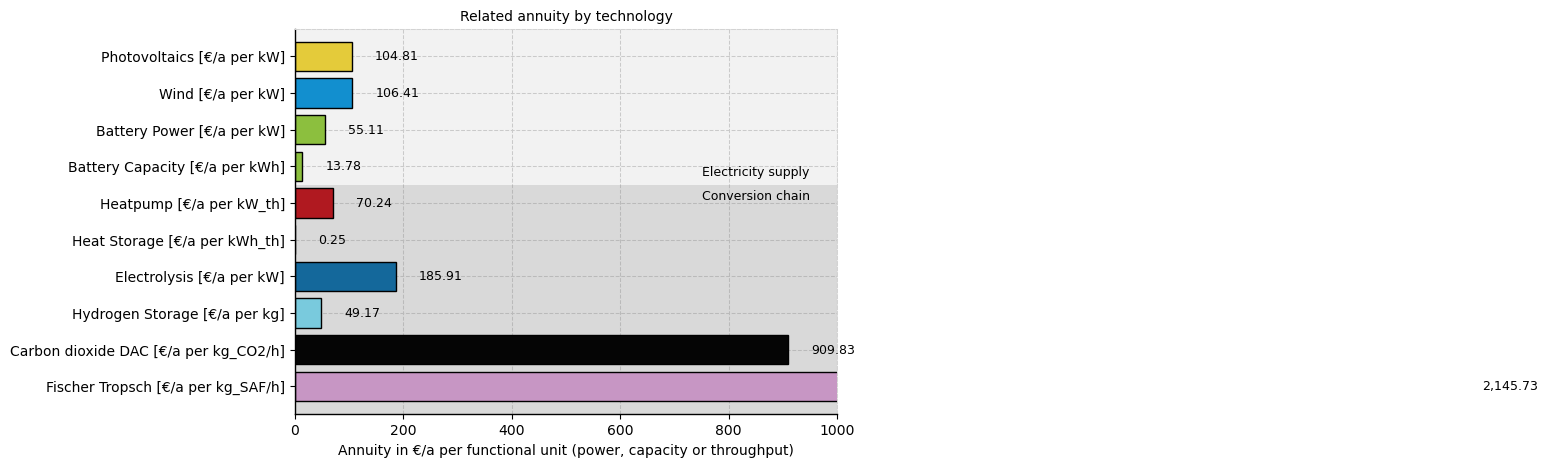

In [11]:
params = ["Fischer Tropsch [€/a per kg_SAF/h]","Carbon dioxide DAC [€/a per kg_CO2/h]", "Hydrogen Storage [€/a per kg]","Electrolysis [€/a per kW]", "Heat Storage [€/a per kWh_th]", "Heatpump [€/a per kW_th]", "Battery Capacity [€/a per kWh]", "Battery Power [€/a per kW]","Wind [€/a per kW]", "Photovoltaics [€/a per kW]"]
values = [annuity_ft, annuity_dac, annuity_h2s, annuity_pem, annuity_qs, annuity_hp, annuity_bat_kapa, annuity_bat_leistung, annuity_wkaon, annuity_pv ]
colors = [col_ft,col_dac,col_h2s,col_pem, col_qs, col_hp, col_bat,col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(750, 5.75, "Electricity supply", fontsize=9, color="black")  
ax.text(750, 5.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(params, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Annuity in €/a per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related annuity by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 1000])

plt.savefig("Bilder/eingangsdaten_annuity_bar.png", dpi=300, bbox_inches='tight')

# 2 Energiesystem 

In [12]:
zeit = pd.date_range('2023-01-01 00:00:00',
                     '2023-12-31 23:00:00',
                     freq='60min')
                     
energysystem = solph.EnergySystem(timeindex=zeit, infer_last_interval=True)

## 2.1 Busse

In [13]:
bus_el = solph.buses.Bus(label="Strom")                                           #Einheit: kWh
energysystem.add(bus_el)

bus_h2 = solph.buses.Bus(label="Wasserstoff")                                     #Einheit: kg
energysystem.add(bus_h2)

bus_q = solph.buses.Bus(label="Waerme")                                           #Einheit: kWh_th
energysystem.add(bus_q)

bus_saf = solph.buses.Bus(label="SAF")                                     #Einheit: kg
energysystem.add(bus_saf)

bus_co2 = solph.buses.Bus(label="Karbondioxid")                                   #Einheit: kg
energysystem.add(bus_co2)

bus_naph = solph.buses.Bus(label="Naphtha")                                     #Einheit: kg
energysystem.add(bus_naph)


## 2.2 Quellen

In [14]:
energysystem.add(
    solph.components.Source(
        label="Wind",
        outputs={bus_el: 
                 solph.flows.Flow(fix=volllaststunden["Wind Südafrika"],                                                                                                                      # P/Pn = (%)
                                  nominal_value = solph.Investment(ep_costs = annuity_wkaon + Eingangsdaten["opex_fix_wkaon"] , maximum=Eingangsdaten["ausbaugrenze_wkaon"]),       # €/kWa + €/kWa     Grenze: kW
                                  variable_costs = Eingangsdaten["opex_var_wkaon"]                                                                                                  # €/kWh 
                                  )}))


energysystem.add(
    solph.components.Source(
        label="PV",
        outputs={bus_el: 
                 solph.flows.Flow(fix=volllaststunden["PV Südafrika"],                                                                                                                        # P/Pn = (%)
                                  nominal_value  = solph.Investment(ep_costs = annuity_pv +  Eingangsdaten["opex_fix_pv"] , maximum=Eingangsdaten["ausbaugrenze_pv"]),              # €/kWa + €/kWa     Grenze: kW
                                  variable_costs = Eingangsdaten["opex_var_pv"]                                                                                                     # €/kWh
                                  )}))
    

energysystem.add(
        solph.components.Source(
            label="Netzbezug",
            outputs={bus_el: 
                     solph.flows.Flow(variable_costs=Eingangsdaten["strompreis"])}))                                                                                                # €/kWh         
    

## 2.3 Senken

In [15]:
energysystem.add(
    solph.components.Sink(
        label="Verkauf_Strom", 
        inputs={bus_el: solph.flows.Flow(variable_costs=Eingangsdaten["stromerloes"])}))                 # - €/kWh


energysystem.add(
    solph.components.Sink(
        label="Verkauf_Wasserstoff", 
        inputs={bus_h2: solph.flows.Flow(variable_costs=Eingangsdaten["wasserstofferloes"])}))           # - €/kg

# Schattenoption für Umweltabgabe, nutzung als Raumwärme etc, da sonst Wärmespeicher notwendig
energysystem.add(
    solph.components.Sink(
        label="Verkauf_Waerme", 
        inputs={bus_q: solph.flows.Flow(variable_costs=Eingangsdaten["waermeerloes"])}))                # - €/kWh_th


energysystem.add(
    solph.components.Sink(
        label="Verkauf_SAF", 
        inputs={bus_saf: solph.flows.Flow(variable_costs=Eingangsdaten["kerosinerloes"])}))             # - €/kg


energysystem.add(
    solph.components.Sink(
        label="Verkauf_Naphtha", 
        inputs={bus_naph: solph.flows.Flow(variable_costs=Eingangsdaten["naphthaerloes"])}))             # - €/kg

## 2.4 Konverter

In [16]:
energysystem.add(
    solph.components.Converter(
        label="elektrolyseur",
        inputs={bus_el: solph.flows.Flow(
            nominal_value=solph.Investment(ep_costs=annuity_pem + Eingangsdaten["capex_pem"]*Eingangsdaten["opex_pem"] ))},                                 # €/kWa + €/kW * %/a
        outputs={bus_h2: solph.flows.Flow()},
        conversion_factors={bus_el: Eingangsdaten["strombedarf_pem"], bus_h2: 1},                                                                           # kWh/kg_H2
       # non_convex=solph.NonConvex(maximum_uptime=60000),                                                                                                  # Lebensdauer Stack begrenzen
        ))                              


energysystem.add(
    solph.components.Converter(
        label="heatpump",
        inputs={bus_el: solph.flows.Flow(
            nominal_value=solph.Investment(ep_costs= annuity_hp/Eingangsdaten["strombedarf_hp"] + Eingangsdaten["capex_hp"]/Eingangsdaten["strombedarf_hp"] * Eingangsdaten["opex_hp"]))},                 # €/(kW_th a) * kW_th/kW_el + €/kW_th *kW_th/kW_el * %/a = €/kW_el a  
        outputs={bus_q: solph.flows.Flow()},
        conversion_factors={bus_el: Eingangsdaten["strombedarf_hp"] , bus_q: 1},))                                                                        


energysystem.add(
    solph.components.Converter(
        label="FischerTropschsynthesis",                                                    
        inputs={
            bus_el: solph.flows.Flow(),
            bus_h2: solph.flows.Flow(),
            bus_co2: solph.flows.Flow()},         
        outputs={
            bus_saf: solph.flows.Flow(fix=volllaststunden["Volllast"],                                                                                   # P/Pn = 1 
                                    nominal_value=Eingangsdaten["produktionskapa_ft"]),
            bus_naph: solph.flows.Flow()},                                                                    # kg/h        
        conversion_factors={
            bus_el: Eingangsdaten["strombedarf_ft"] , bus_h2: Eingangsdaten["h2_bedarf_ft"] ,bus_co2: Eingangsdaten["co2_bedarf_ft"], bus_saf: 1 , bus_naph: Eingangsdaten["naphtha_output_ft"]},))         # kWh/kg, kg_H2/kg, kg_co2/kg


energysystem.add(
    solph.components.Converter(
        label="dac",
        inputs={bus_el: solph.flows.Flow(
            nominal_value=solph.Investment(ep_costs= annuity_dac/Eingangsdaten["strombedarf_dac"] + Eingangsdaten["capex_dac"]/Eingangsdaten["strombedarf_dac"] * Eingangsdaten["opex_dac"])),               # €*h/(kg*a) *kg/kWh + €*h/kg *kg/kWh * %/a = €h/kWha
            bus_q: solph.flows.Flow()},                  
        outputs={bus_co2: solph.flows.Flow()},
        conversion_factors={bus_el: Eingangsdaten["strombedarf_dac"], bus_q: Eingangsdaten["waerme_bedarf_dac"] , bus_co2: 1},))                                                                        # kWh/kg

## 2.5 Speicher

In [17]:
wasserstofftank = solph.components.GenericStorage(                              
    nominal_storage_capacity=solph.Investment(ep_costs = annuity_h2s + Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"]),               # €*h/(kg*a) + €*h/kg * %/a 
    label="h2s",
    inputs={bus_h2: solph.flows.Flow()},                
    outputs={bus_h2: solph.flows.Flow()},                         
    loss_rate=Eingangsdaten["verlustrate_h2s"] ,                                                                                              # %_Kapa/h 
    initial_storage_level=Eingangsdaten["fuellstand_h2s"] ,                                                                                   # %_Kapa
    inflow_conversion_factor=Eingangsdaten["eta_einspeichern_h2s"] ,                                                                          # %
    outflow_conversion_factor=Eingangsdaten["eta_ausspeichern_h2s"] ,                                                                         # %
    invest_relation_input_capacity = 1,                                                                                                       # legt abhängig von Kapazität Ein/Ausspeicherleistung fest / C-Rate
    invest_relation_output_capacity= 1,                                          
)

energysystem.add(wasserstofftank)
    
  
batterie = solph.components.GenericStorage(                              
    #nominal_storage_capacity=solph.Investment(ep_costs=annuity_bat_kapa + Eingangsdaten["c_rate_bat"] * annuity_bat_leistung),              # €/(kWh*a) + kw/kwh * €/(kW*a) =  €/(kWh*a)
    nominal_storage_capacity=solph.Investment(ep_costs=annuity_bat_kapa + Eingangsdaten["c_rate_bat"] * annuity_bat_leistung + Eingangsdaten["opex_fix_bat"]*Eingangsdaten["capex_bat_kapa"]),              # €/(kWh*a) + kw/kwh * €/(kW*a) + %/a * €/kWh=  €/(kWh*a)                            
    label="Batterie",
    inputs={bus_el: solph.flows.Flow()},                
    outputs={bus_el: solph.flows.Flow()},                         
    loss_rate = Eingangsdaten["verlustrate_bat"]/24,                                                                                        # %/d * d/24h = %/h
    initial_storage_level=Eingangsdaten["fuellstand_bat"] ,                                                                                 # %_Kapa
    inflow_conversion_factor=Eingangsdaten["eta_einspeichern_bat"] ,                                                                        # %
    outflow_conversion_factor= Eingangsdaten["eta_ausspeichern_bat"] ,                                                                      # %
    invest_relation_input_capacity = Eingangsdaten["c_rate_bat"],                                                                           # kW/kWh
    invest_relation_output_capacity= Eingangsdaten["c_rate_bat"],                                   
)

energysystem.add(batterie)



waermespeicher = solph.components.GenericStorage(                              
    nominal_storage_capacity=solph.Investment(ep_costs=annuity_qs + Eingangsdaten["opex_qs"] * Eingangsdaten["capex_qs"] ),                 # €/kWh_th a + %/a * €/kWh_th = €/a per kWh_th                           
    label="qs",
    inputs={bus_q: solph.flows.Flow()},                
    outputs={bus_q: solph.flows.Flow()},                         
    loss_rate = Eingangsdaten["verlustrate_qs"],                                                                                           # %/h
    initial_storage_level=Eingangsdaten["fuellstand_qs"] ,                                                                                 # %_Kapa
    inflow_conversion_factor=Eingangsdaten["eta_einspeichern_qs"] ,                                                                        # %
    outflow_conversion_factor= Eingangsdaten["eta_ausspeichern_qs"] ,                                                                      # %
    invest_relation_input_capacity = 1,                                                                           
    invest_relation_output_capacity= 1,                                   
)

energysystem.add(waermespeicher)


## 2.6 Modellauf

In [18]:
model = solph.Model(energysystem)
model.solve(solver='gurobi')
Ergebnisse = solph.processing.results(model)

# 3 Postprocessing

## 3.1 Auslesen der Ergebnisse

### 3.1.1 Busse

In [19]:
# Keine weitere extraktion, da selben ergebnisse wie unten bei Quellen, Konverter, Speicher und Senken
result_strombus = solph.views.node(Ergebnisse, 'Strom')
result_h2bus = solph.views.node(Ergebnisse, 'Wasserstoff')
result_co2bus = solph.views.node(Ergebnisse, 'Karbondioxid')
result_safbus = solph.views.node(Ergebnisse, 'SAF')
result_qbus = solph.views.node(Ergebnisse, 'Waerme')
result_naphbus = solph.views.node(Ergebnisse, 'Naphtha')

### 3.1.2 Quellen

In [20]:
result_strombezug = solph.views.node(Ergebnisse, 'Netzbezug')
result_strombezug_flow = result_strombezug['sequences'][(('Netzbezug', 'Strom'), 'flow')]   # kWh/h

result_wka = solph.views.node(Ergebnisse, 'Wind')
result_wka_invest = result_wka['scalars'][(('Wind', 'Strom'), 'invest')]                    # ? gleiche wie total
result_wka_leistung = result_wka['scalars'][(('Wind', 'Strom'), 'total')]                   # kW
result_wka_flow_generation = result_wka['sequences'][(('Wind', 'Strom'), 'flow')]           # kWh/h

result_pv = solph.views.node(Ergebnisse, 'PV')
result_pv_invest = result_pv['scalars'][(('PV', 'Strom'), 'invest')]                        # ? gleiche wie total
result_pv_leistung = result_pv['scalars'][(('PV', 'Strom'), 'total')]                       # kW
result_pv_flow_generation = result_pv['sequences'][(('PV', 'Strom'), 'flow')]               # kWh/h

Ergebnisse_df.loc["result_wka_leistung", "Wert"] = result_wka_leistung
Ergebnisse_df.loc["result_pv_leistung", "Wert"] = result_pv_leistung


### 3.1.3 Senken

In [21]:
result_stromverkauf = solph.views.node(Ergebnisse, 'Verkauf_Strom')
result_stromverkauf_flow = result_stromverkauf['sequences'][(('Strom', 'Verkauf_Strom'), 'flow')]             # kWh/h ?

result_h2verkauf = solph.views.node(Ergebnisse, 'Verkauf_Wasserstoff')
result_h2verkauf_flow = result_h2verkauf['sequences'][(('Wasserstoff', 'Verkauf_Wasserstoff'), 'flow')]       # kg_H2/h *8760h ?

result_qverkauf = solph.views.node(Ergebnisse, 'Verkauf_Waerme')
result_qverkauf_flow = result_qverkauf['sequences'][(('Waerme', 'Verkauf_Waerme'), 'flow')]      

result_safverkauf = solph.views.node(Ergebnisse, 'Verkauf_SAF')
result_safverkauf_flow = result_safverkauf['sequences'][(('SAF', 'Verkauf_SAF'), 'flow')]           # kg_ch3oh/h *8760h ?

result_naphverkauf = solph.views.node(Ergebnisse, 'Verkauf_Naphtha')
result_naphverkauf_flow = result_naphverkauf['sequences'][(('Naphtha', 'Verkauf_Naphtha'), 'flow')] 

### 3.1.4 Konverter

In [22]:
result_pem = solph.views.node(Ergebnisse, 'elektrolyseur')
result_pem_invest = result_pem['scalars'][(('Strom', 'elektrolyseur'), 'invest')]                   # gleiche wie total
result_pem_leistung = result_pem['scalars'][(('Strom', 'elektrolyseur'), 'total')]                  # kW
result_pem_flow_elin = result_pem['sequences'][(('Strom', 'elektrolyseur'), 'flow')]                # kWh/h
result_pem_flow_h2out = result_pem['sequences'][(('elektrolyseur', 'Wasserstoff'), 'flow')]         # kg/h *8760h ?

result_dac = solph.views.node(Ergebnisse, 'dac')
result_dac_invest = result_dac['scalars'][(('Strom', 'dac'), 'invest')]                             # gleiche wie total
result_dac_leistung = result_dac['scalars'][(('Strom', 'dac'), 'total')]                            # kW
result_dac_flow_elin = result_dac['sequences'][(('Strom', 'dac'), 'flow')]                          # kWh/h
result_dac_flow_co2out = result_dac['sequences'][(('dac', 'Karbondioxid'), 'flow')]                  # kg/h *8760h ?
result_dac_flow_qin = result_dac['sequences'][(('Waerme', 'dac'), 'flow')] 

result_ft = solph.views.node(Ergebnisse, 'FischerTropschsynthesis')
result_ft_flow_co2in = result_ft['sequences'][(('Karbondioxid', 'FischerTropschsynthesis'), 'flow')]
result_ft_flow_h2in = result_ft['sequences'][(('Wasserstoff', 'FischerTropschsynthesis'), 'flow')]
result_ft_flow_elin = result_ft['sequences'][(('Strom', 'FischerTropschsynthesis'), 'flow')]
result_ft_flow_safout = result_ft['sequences'][(('FischerTropschsynthesis', 'SAF' ), 'flow')]
result_ft_flow_naphout = result_ft['sequences'][(('FischerTropschsynthesis', 'Naphtha' ), 'flow')]

result_hp = solph.views.node(Ergebnisse, 'heatpump')
result_hp_invest = result_hp['scalars'][(('Strom', 'heatpump'), 'invest')]                   # gleiche wie total
result_hp_leistung = result_hp['scalars'][(('Strom', 'heatpump'), 'total')]                  # kW
result_hp_flow_elin = result_hp['sequences'][(('Strom', 'heatpump'), 'flow')]                # kWh/h
result_hp_flow_qout = result_hp['sequences'][(('heatpump', 'Waerme'), 'flow')]               # kWh_th/h


Ergebnisse_df.loc["result_pem_leistung", "Wert"] = result_pem_leistung
Ergebnisse_df.loc["result_dac_leistung", "Wert"] = result_dac_leistung
Ergebnisse_df.loc["result_hp_leistung", "Wert"] = result_hp_leistung

### 3.1.5 Speicher

In [23]:
result_h2s = solph.views.node(Ergebnisse, 'h2s')
result_h2s_invest = result_h2s['scalars'][(('Wasserstoff', 'h2s'), 'invest')]                           # ? gleiche wie total
result_h2s_kapa = result_h2s['scalars'][(('Wasserstoff', 'h2s'), 'total')]                              # kg
# noch öfter die selbe Zahl? wieso? worin liegen die unterschiede der Outputs?
result_h2s_initcontent = result_h2s['scalars'][(('h2s', 'None'), 'init_content')]                       # kg
result_h2s_flow_in = result_h2s['sequences'][(('Wasserstoff', 'h2s'), 'flow')]                          # kg/h *8760h ?
result_h2s_flow_out = result_h2s['sequences'][(('h2s', 'Wasserstoff'), 'flow')]                         # kg/h *8760h ?
result_h2s_flow_storagecontent = result_h2s['sequences'][(('h2s', 'None'), 'storage_content')]          # kg/h *8760h ?


result_bat = solph.views.node(Ergebnisse, 'Batterie')
result_bat_invest = result_bat['scalars'][(('Batterie', 'Strom'), 'invest')]                            # kW
result_bat_leistung = result_bat['scalars'][(('Batterie', 'Strom'), 'total')]                           # kW
result_bat_initcontent = result_bat['scalars'][(('Batterie', 'None'), 'init_content')]                  # kWh
result_bat_kapa = result_bat['scalars'][(('Batterie', 'None'), 'invest')]                               # kWh
#result_bat_leistung2 = result_bat['scalars'][(('Batterie', 'Strom'), 'total')]                         # kW
result_bat_flow_out = result_bat['sequences'][(('Batterie', 'Strom'), 'flow')]                          # kWh/h
result_bat_flow_in = result_bat['sequences'][(('Strom', 'Batterie'), 'flow')]                           # kWh/h
result_bat_flow_storagecontent = result_bat['sequences'][(('Batterie', 'None'), 'storage_content')]     # kWh/h ?


result_qs = solph.views.node(Ergebnisse, 'qs')
result_qs_invest = result_qs['scalars'][(('Waerme', 'qs'), 'invest')]                           # ? gleiche wie total
result_qs_kapa = result_qs['scalars'][(('Waerme', 'qs'), 'total')]                              # kWh
result_qs_initcontent = result_qs['scalars'][(('qs', 'None'), 'init_content')]                  # kWh
result_qs_flow_in = result_qs['sequences'][(('Waerme', 'qs'), 'flow')]                          # kWh *8760h
result_qs_flow_out = result_qs['sequences'][(('qs', 'Waerme'), 'flow')]                         # kWh *8760h
result_qs_flow_storagecontent = result_qs['sequences'][(('qs', 'None'), 'storage_content')]     # kWh *8760h


Ergebnisse_df.loc["result_h2s_kapa", "Wert"] = result_h2s_kapa
Ergebnisse_df.loc["result_bat_leistung", "Wert"] = result_bat_leistung
Ergebnisse_df.loc["result_bat_kapa", "Wert"] = result_bat_kapa
Ergebnisse_df.loc["result_qs_kapa", "Wert"] = result_qs_kapa

## 3.2 Darstellung der Ergebnisse

### 3.2.1 Darstellung der Scalars

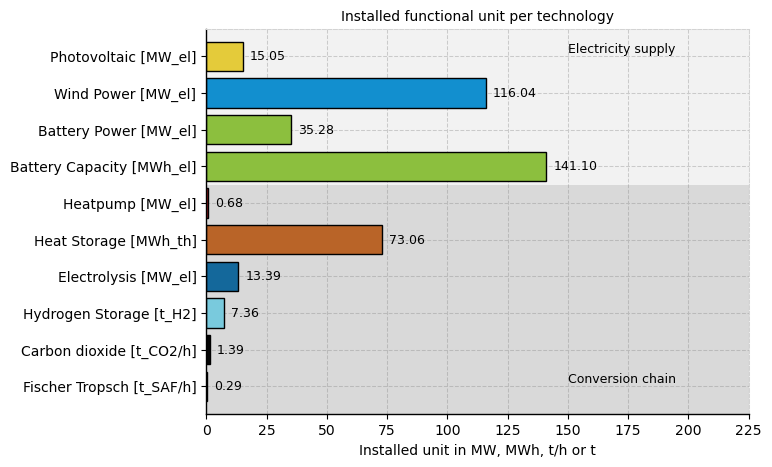

In [24]:
categories = ["Fischer Tropsch [t_SAF/h]", "Carbon dioxide [t_CO2/h]", "Hydrogen Storage [t_H2]", "Electrolysis [MW_el]", "Heat Storage [MWh_th]" , "Heatpump [MW_el]", "Battery Capacity [MWh_el]", "Battery Power [MW_el]", "Wind Power [MW_el]", "Photovoltaic [MW_el]"]
values = [Eingangsdaten['produktionskapa_ft'] / 1000, result_dac_leistung / Eingangsdaten["strombedarf_dac"] / 1000, result_h2s_kapa / 1000, result_pem_leistung / 1000, result_qs_kapa/1000, result_hp_leistung/1000, result_bat_kapa/1000, result_bat_leistung / 1000, result_wka_leistung / 1000, result_pv_leistung / 1000]
colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(5.5, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 5.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(150, 9.1, "Electricity supply", fontsize=9, color="black")  
ax.text(150, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

# Zahlenwerte neben den Balken anzeigen
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Installed unit in MW, MWh, t/h or t", fontsize=10)
plt.title("Installed functional unit per technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 225])

plt.savefig("Bilder/result_leistungen_bar.png", dpi=300, bbox_inches='tight')

### 3.2.2 Darstellung der Flows

In [25]:
startdatum = "2023-06-01 00:00:00"
enddatum = pd.to_datetime(startdatum) + pd.Timedelta(days=359) #immer einen Tag abzug da der letzte tag noch vollständig geplottet wird 60 Tage anzeigen --> days=59)
tickinterval = 60 # Abstand in Tagen zwischen den x Achsen Daten label

#### 3.2.2.1 Stromerzeugung und Bezug

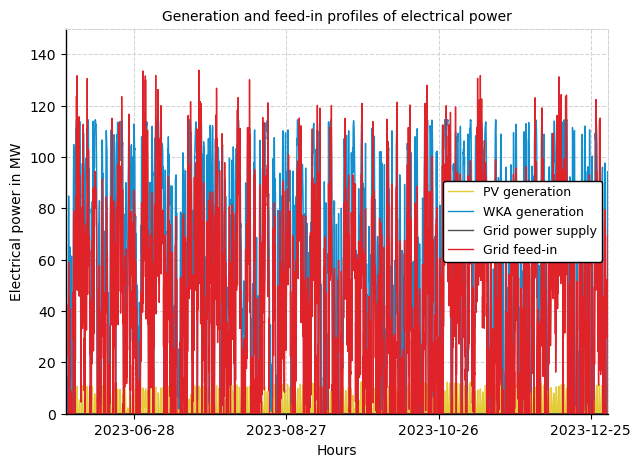

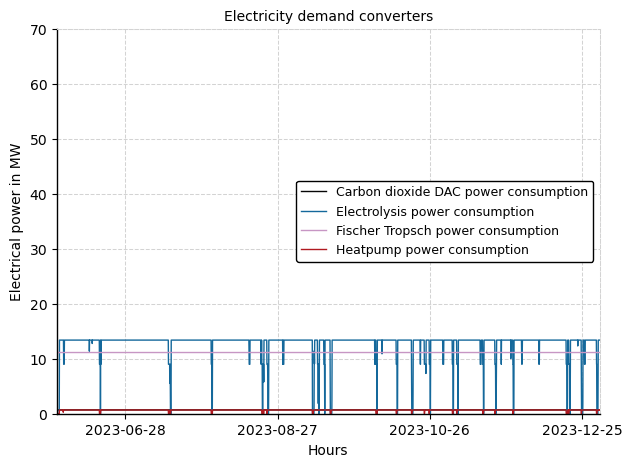

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(result_pv_flow_generation[startdatum:enddatum]/1000, label="PV generation", color=col_pv, linewidth=1)
plt.plot(result_wka_flow_generation[startdatum:enddatum]/1000, label="WKA generation", color=col_wka, linewidth=1)
plt.plot(result_strombezug_flow[startdatum:enddatum]/1000, label="Grid power supply", color=col_buy, linewidth=1)
plt.plot(result_stromverkauf_flow[startdatum:enddatum]/1000, label="Grid feed-in", color=col_sell, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 150)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Generation and feed-in profiles of electrical power", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_quellen_senken.png", dpi=300, bbox_inches='tight') 
plt.show()


##################################################################

plt.figure(figsize=(7, 5))
plt.plot(result_dac_flow_elin[startdatum:enddatum]/1000, label="Carbon dioxide DAC power consumption", color=col_dac, linewidth=1)
plt.plot(result_pem_flow_elin[startdatum:enddatum]/1000, label="Electrolysis power consumption", color=col_pem, linewidth=1)
plt.plot(result_ft_flow_elin[startdatum:enddatum]/1000, label="Fischer Tropsch power consumption", color=col_ft, linewidth=1)
plt.plot(result_hp_flow_elin[startdatum:enddatum]/1000, label ="Heatpump power consumption", color=col_hp, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 70)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))



plt.title("Electricity demand converters", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_konverter.png", dpi=300, bbox_inches='tight')
plt.show()


#### 3.2.2.2 Batteriespeicher

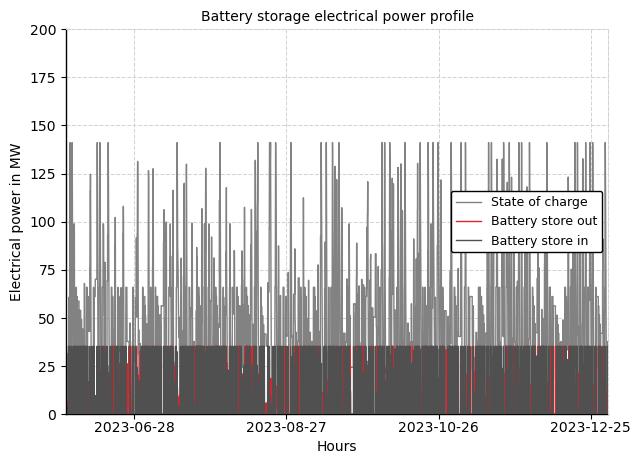

In [27]:
plt.figure(figsize=(7, 5))
plt.plot(result_bat_flow_storagecontent[startdatum:enddatum]/1000, label="State of charge", color=col_etc, linewidth=1)
plt.plot(result_bat_flow_out[startdatum:enddatum]/1000, label="Battery store out", color=col_sell, linewidth=1)
plt.plot(result_bat_flow_in[startdatum:enddatum]/1000, label="Battery store in", color=col_buy, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_zorder(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 200)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Battery storage electrical power profile", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)
plt.tick_params(axis='x', labelsize=10, rotation=0, pad=1)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_batterie.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.2.3 Wasserstoff

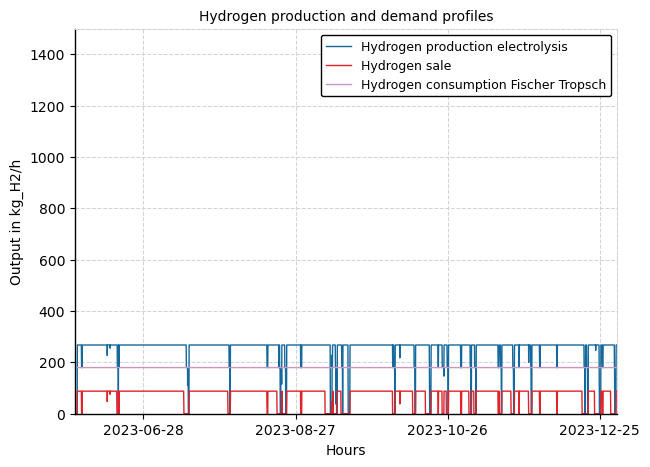

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(result_pem_flow_h2out[startdatum:enddatum], label="Hydrogen production electrolysis", color=col_pem, linewidth=1)
plt.plot(result_h2verkauf_flow[startdatum:enddatum], label='Hydrogen sale', color=col_sell, linewidth=1)
plt.plot(result_ft_flow_h2in[startdatum:enddatum], label="Hydrogen consumption Fischer Tropsch", color=col_ft, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 1500)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Hydrogen production and demand profiles", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_H2/h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)
plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_wasserstoff.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.2.4 Wasserstoffspeicher

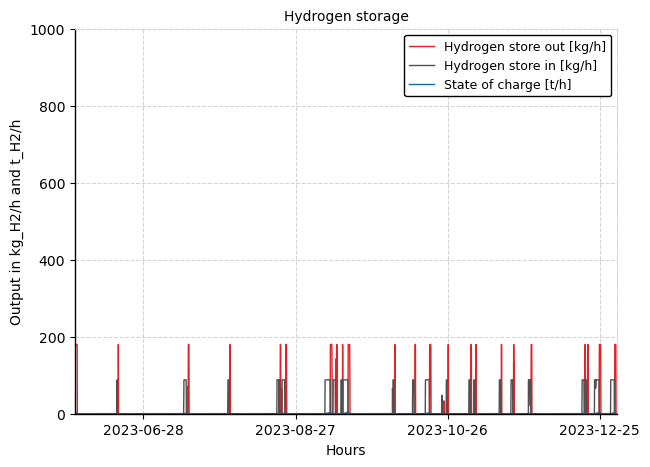

In [29]:
plt.figure(figsize=(7, 5))

plt.plot(result_h2s_flow_out[startdatum:enddatum], label="Hydrogen store out [kg/h]", color=col_sell, linewidth=1)
plt.plot(result_h2s_flow_in[startdatum:enddatum], label="Hydrogen store in [kg/h]", color=col_buy, linewidth=1)
plt.plot(result_h2s_flow_storagecontent[startdatum:enddatum]/1000, label="State of charge [t/h]", color=col_h2, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
#ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(0, 1000)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Hydrogen storage", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_H2/h and t_H2/h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_wasserstoff_speicher.png", dpi=300, bbox_inches='tight')

plt.show()

#### 3.2.2.5 Kerosin

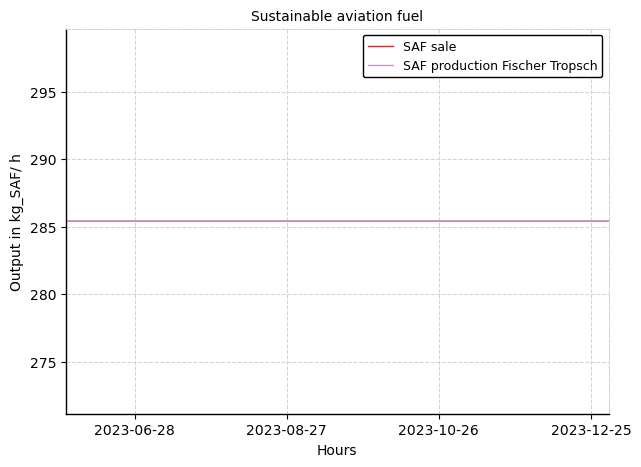

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(result_safverkauf_flow[startdatum:enddatum], label="SAF sale", color=col_sell, linewidth=1)
plt.plot(result_ft_flow_safout[startdatum:enddatum], label="SAF production Fischer Tropsch", color=col_ft, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
#plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Sustainable aviation fuel", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_SAF/ h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_SAF.png", dpi=300, bbox_inches='tight') 

plt.show()

#### 3.2.2.6 Carbon dioxide

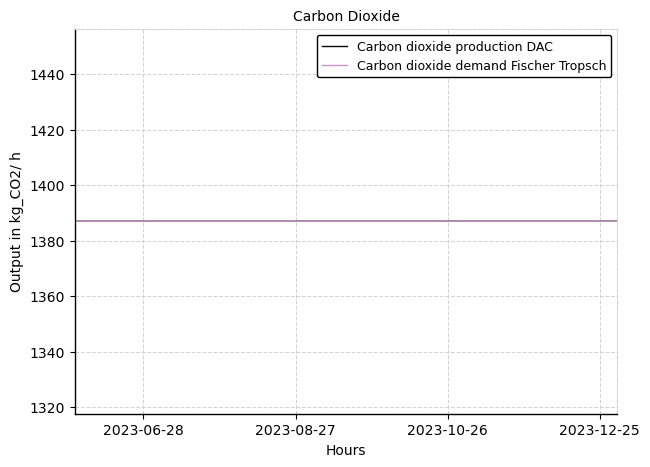

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(result_dac_flow_co2out[startdatum:enddatum], label="Carbon dioxide production DAC", color=col_dac, linewidth=1)
plt.plot(result_ft_flow_co2in[startdatum:enddatum], label="Carbon dioxide demand Fischer Tropsch", color=col_ft, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
#plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Carbon Dioxide", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_CO2/ h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_carbon.png", dpi=300, bbox_inches='tight') 

plt.show()

#### 3.2.2.7 Heat

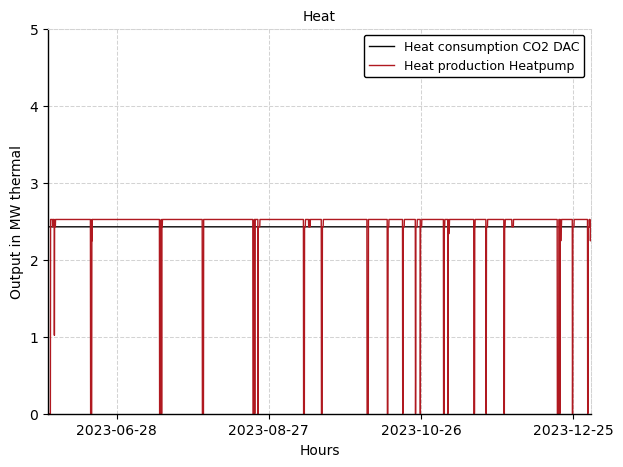

In [32]:
plt.figure(figsize=(7, 5))
plt.plot(result_dac_flow_qin[startdatum:enddatum]/1000, label="Heat consumption CO2 DAC", color=col_dac, linewidth=1)
plt.plot(result_hp_flow_qout[startdatum:enddatum]/1000, label="Heat production Heatpump", color=col_hp, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 5)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Heat", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in MW thermal", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_carbon.png", dpi=300, bbox_inches='tight') 

plt.show()

#### 3.2.2.8 Wärmespeicher

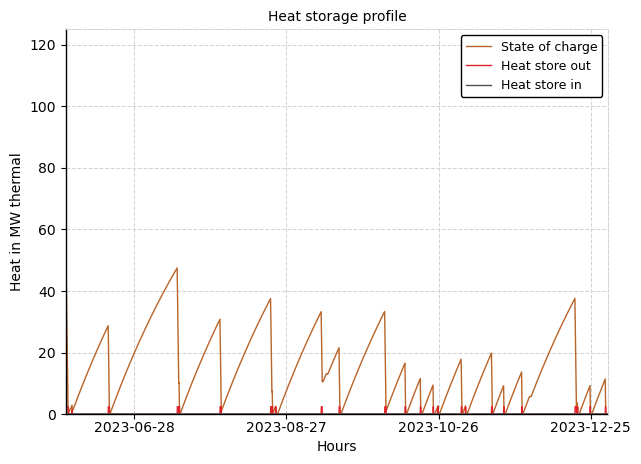

In [33]:
plt.figure(figsize=(7, 5))
plt.plot(result_qs_flow_storagecontent[startdatum:enddatum]/1000, label="State of charge", color=col_qs, linewidth=1)
plt.plot(result_qs_flow_out[startdatum:enddatum]/1000, label="Heat store out", color=col_sell, linewidth=1)
plt.plot(result_qs_flow_in[startdatum:enddatum]/1000, label="Heat store in", color=col_buy, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_zorder(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 125)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Heat storage profile", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Heat in MW thermal", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)
plt.tick_params(axis='x', labelsize=10, rotation=0, pad=1)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_heat_storage.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.2.9 Naphtha

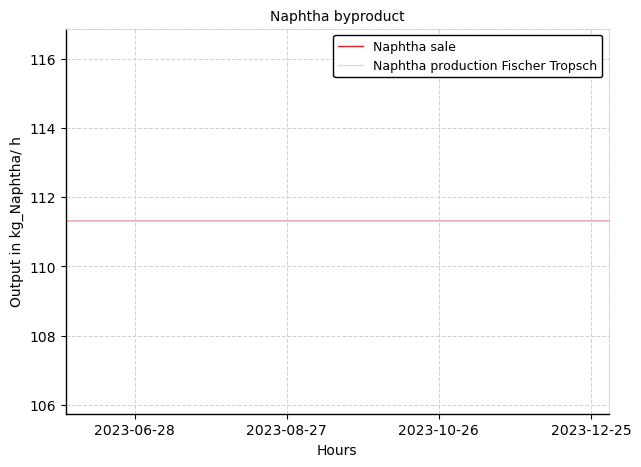

In [34]:
plt.figure(figsize=(7, 5))
plt.plot(result_naphverkauf_flow[startdatum:enddatum], label="Naphtha sale", color=col_sell, linewidth=1)
plt.plot(result_ft_flow_naphout[startdatum:enddatum], label="Naphtha production Fischer Tropsch", color=col_naph, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
#plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Naphtha byproduct", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_Naphtha/ h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_Naphtha.png", dpi=300, bbox_inches='tight') 

plt.show()

# 4 Berechnungen

## 4.1 Flow Summen

### 4.1.1 Elektrische Energie in kWh/a

In [35]:
# Quellen
result_strombezug_flowsum = result_strombezug_flow.sum()
result_wka_flowsum_generation = result_wka_flow_generation.sum()
result_pv_flowsum_generation = result_pv_flow_generation.sum()

Ergebnisse_df.loc["result_strombezug_flowsum", "Wert"] = result_strombezug_flowsum / 1000
Ergebnisse_df.loc["result_wka_flowsum_generation", "Wert"] = result_wka_flowsum_generation / 1000
Ergebnisse_df.loc["result_pv_flowsum_generation", "Wert"] = result_pv_flowsum_generation / 1000


# Konverter
result_pem_flowsum_elin = result_pem_flow_elin.sum()
result_dac_flowsum_elin = result_dac_flow_elin.sum()
result_ft_flowsum_elin = result_ft_flow_elin.sum()
result_hp_flowsum_elin = result_hp_flow_elin.sum()

Ergebnisse_df.loc["result_pem_flowsum_elin", "Wert"] = result_pem_flowsum_elin / 1000
Ergebnisse_df.loc["result_dac_flowsum_elin", "Wert"] = result_dac_flowsum_elin / 1000
Ergebnisse_df.loc["result_ft_flowsum_elin", "Wert"] = result_ft_flowsum_elin / 1000
Ergebnisse_df.loc["result_hp_flowsum_elin", "Wert"] = result_hp_flowsum_elin / 1000


# Speicher
result_bat_flowsum_out = result_bat_flow_out.sum()
result_bat_flowsum_in = result_bat_flow_in.sum()

Ergebnisse_df.loc["result_bat_flowsum_out", "Wert"] = result_bat_flowsum_out / 1000
Ergebnisse_df.loc["result_bat_flowsum_in", "Wert"] = result_bat_flowsum_in / 1000


# Senken
result_stromverkauf_flowsum = result_stromverkauf_flow.sum()
Ergebnisse_df.loc["result_stromverkauf_flowsum", "Wert"] = result_stromverkauf_flowsum / 1000


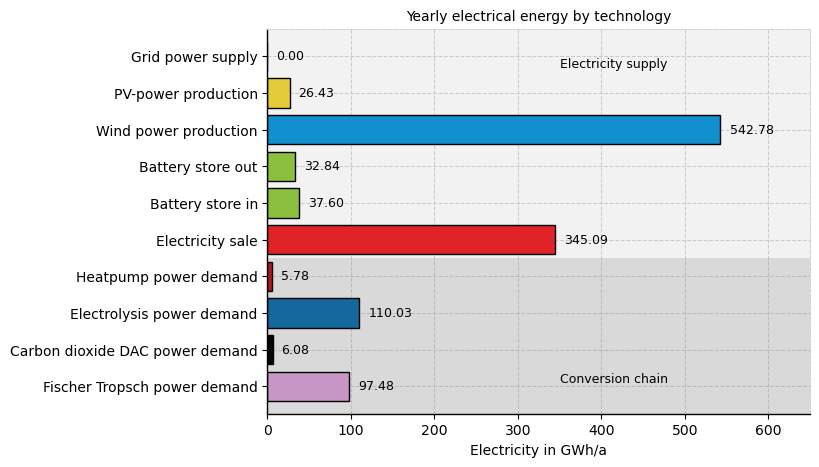

In [36]:
categories = [
"Fischer Tropsch power demand", "Carbon dioxide DAC power demand", "Electrolysis power demand", "Heatpump power demand",
"Electricity sale","Battery store in", "Battery store out",
"Wind power production", "PV-power production",
"Grid power supply"
]

values = [
result_ft_flowsum_elin / 1000000, result_dac_flowsum_elin / 1000000, result_pem_flowsum_elin / 1000000, result_hp_flowsum_elin/1000000,
result_stromverkauf_flowsum / 1000000, result_bat_flowsum_in / 1000000, result_bat_flowsum_out / 1000000,
result_wka_flowsum_generation / 1000000, result_pv_flowsum_generation / 1000000,
result_strombezug_flowsum / 1000000
]

colors = [col_ft, col_dac, col_pem, col_hp, col_sell, col_bat, col_bat, col_wka, col_pv, col_buy]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(350, 8.7, "Electricity supply", fontsize=9, color="black")  
ax.text(350, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Electricity in GWh/a", fontsize=10)
plt.title("Yearly electrical energy by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 650])

plt.savefig("Bilder/result_stromfluesse_bar.png", dpi=300, bbox_inches='tight')

### 4.1.2 Elektrische Energie Bilanz

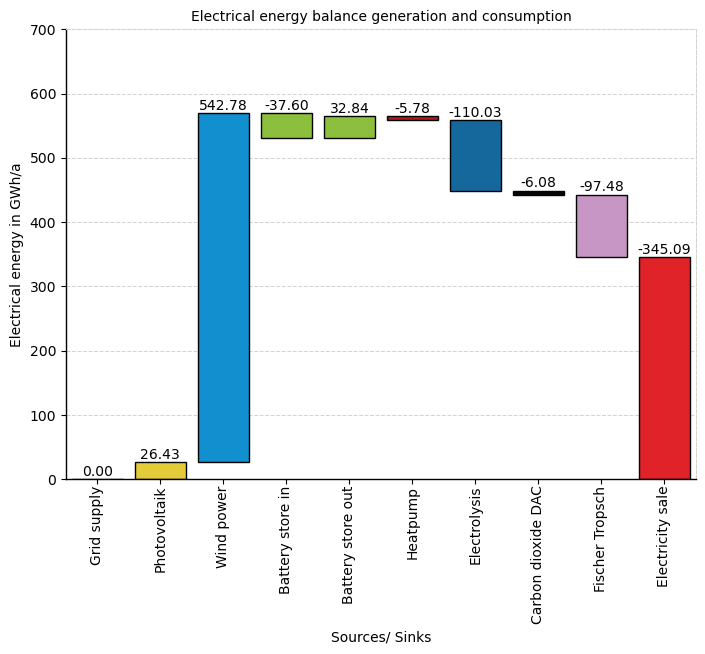

In [37]:
labels = ["Grid supply","Photovoltaik", "Wind power", "Battery store in", "Battery store out", "Heatpump", "Electrolysis", "Carbon dioxide DAC", "Fischer Tropsch", "Electricity sale" ]
colors = [col_buy, col_pv, col_wka , col_bat, col_bat, col_hp, col_pem, col_dac, col_ft, col_sell]
values = [result_strombezug_flowsum/1000000,
          result_pv_flowsum_generation/1000000,
          result_wka_flowsum_generation/1000000,
          -result_bat_flowsum_in/1000000,
          result_bat_flowsum_out/1000000,
          -result_hp_flowsum_elin/1000000,
          -result_pem_flowsum_elin/1000000,
          -result_dac_flowsum_elin/1000000,
          -result_ft_flowsum_elin/1000000,
          -result_stromverkauf_flowsum/1000000
          ]

running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))

ax = plt.gca()

# cut = 5.5
# ax.axvspan(-0.5, cut, facecolor=col_etc, alpha=0.1)   # Links
# ax.axvspan(cut, 9.5, facecolor=col_etc, alpha=0.3)    # Rechts
# ax.text(0.75, max(running_total) + 3, "Electricity supply", fontsize=9, color="black", ha='center')
# ax.text(7, max(running_total) + 3, "Conversion chain", fontsize=9, color="black", ha='center')


bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

# Werte an die Balken hinzufügen (immer oberhalb)
for bar, value in zip(bars, values):
    height = bar.get_height()
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)


ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(min(running_total), max(running_total) + 5)
plt.xlim(-0.5, 9.5)
plt.ylim(0,700)

plt.title("Electrical energy balance generation and consumption", fontsize=10)
plt.ylabel("Electrical energy in GWh/a", fontsize=10)
plt.xlabel("Sources/ Sinks")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=90, pad=1)
plt.tick_params(axis='y', labelsize=10, rotation=0)



plt.savefig("Bilder/calc_strombilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()

### 4.1.3 Coversion Chain flows 

In [38]:
# Senken
result_h2verkauf_flowsum = result_h2verkauf_flow.sum()
result_safverkauf_flowsum = result_safverkauf_flow.sum()
result_qverkauf_flowsum = result_qverkauf_flow.sum()
result_naphverkauf_flowsum = result_naphverkauf_flow.sum()

Ergebnisse_df.loc["result_safverkauf_flowsum", "Wert"] = result_safverkauf_flowsum
Ergebnisse_df.loc["result_h2verkauf_flowsum", "Wert"] = result_h2verkauf_flowsum
Ergebnisse_df.loc["result_qverkauf_flowsum", "Wert"] = result_qverkauf_flowsum
Ergebnisse_df.loc["result_naphverkauf_flowsum", "Wert"] = result_naphverkauf_flowsum

# Speicher
result_h2s_flowsum_in = result_h2s_flow_in.sum()
result_h2s_flowsum_out = result_h2s_flow_out.sum()
result_qs_flowsum_in = result_qs_flow_in.sum()
result_qs_flowsum_out = result_qs_flow_out.sum()

Ergebnisse_df.loc["result_h2s_flowsum_in", "Wert"] = result_h2s_flowsum_in
Ergebnisse_df.loc["result_h2s_flowsum_out", "Wert"] = result_h2s_flowsum_out
Ergebnisse_df.loc["result_qs_flowsum_in", "Wert"] = result_qs_flowsum_in
Ergebnisse_df.loc["result_qs_flowsum_out", "Wert"] = result_qs_flowsum_out


# Konverter
result_pem_flowsum_h2out = result_pem_flow_h2out.sum()
result_dac_flowsum_co2out = result_dac_flow_co2out.sum()
result_dac_flowsum_qin = result_dac_flow_qin.sum()
result_ft_flowsum_safout = result_ft_flow_safout.sum()
result_ft_flowsum_h2in = result_ft_flow_h2in.sum()
result_ft_flowsum_co2in = result_ft_flow_co2in.sum()
result_hp_flowsum_qout = result_hp_flow_qout.sum()
result_ft_flowsum_naphout = result_ft_flow_naphout.sum()

Ergebnisse_df.loc["result_pem_flowsum_h2out", "Wert"] = result_pem_flowsum_h2out
Ergebnisse_df.loc["result_dac_flowsum_co2out", "Wert"] = result_dac_flowsum_co2out
Ergebnisse_df.loc["result_dac_flowsum_qin", "Wert"] = result_dac_flowsum_qin
Ergebnisse_df.loc["result_ft_flowsum_safout", "Wert"] = result_ft_flowsum_safout
Ergebnisse_df.loc["result_ft_flowsum_h2in", "Wert"] = result_ft_flowsum_h2in
Ergebnisse_df.loc["result_ft_flowsum_co2in", "Wert"] = result_ft_flowsum_co2in
Ergebnisse_df.loc["result_hp_flowsum_qout", "Wert"] = result_hp_flowsum_qout
Ergebnisse_df.loc["result_ft_flowsum_naphout", "Wert"] = result_ft_flowsum_naphout

#### 4.1.3.1 Heat flows 

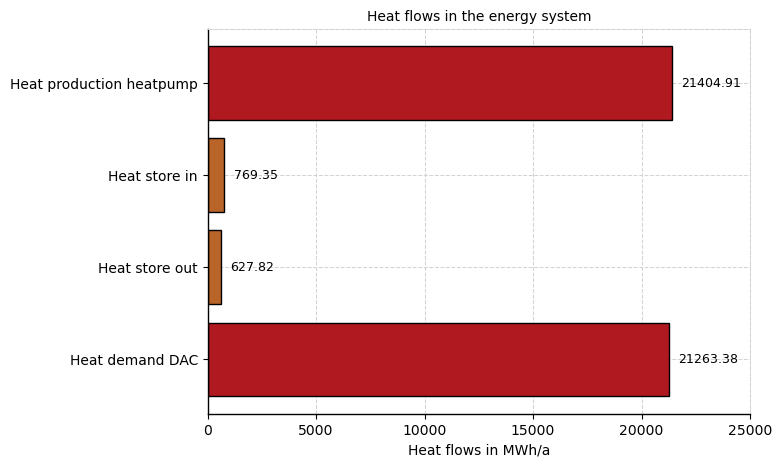

In [39]:
categories = [

    "Heat demand DAC",
    "Heat store out",
    "Heat store in",
    "Heat production heatpump"
]

values = [

    result_dac_flowsum_qin/1000,
    result_qs_flowsum_out/1000,
    result_qs_flowsum_in/1000,
    result_hp_flowsum_qout/1000,

]                 

#colors = [col_sell,col_ft,col_ft,col_dac, col_dac, col_qs, col_qs, col_hp,col_sell,col_ft,col_h2s,col_h2s,col_pem]
colors = [ col_q, col_qs, col_qs, col_q]

fig, ax = plt.subplots(figsize=(7, 5))

# ax.axhspan(-0.75, 9, facecolor=col_etc, alpha=0.3)
# ax.set_ylim([-0.75, len(values)-0.25])


bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Heat flows in MWh/a", fontsize=10)
plt.title("Heat flows in the energy system", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 25000])

plt.savefig("Bilder/result_waermestroeme_bar.png", dpi=300, bbox_inches='tight')


#### 4.1.3.2 Massenströme 

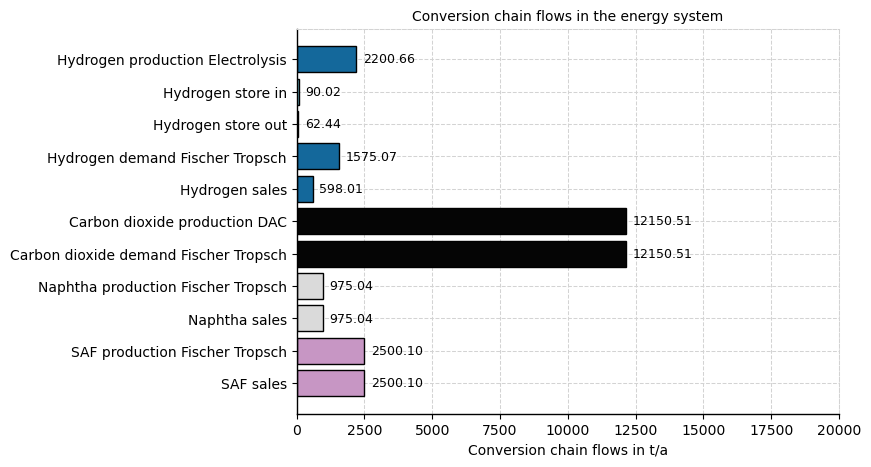

In [40]:
categories = [
    "SAF sales",
    "SAF production Fischer Tropsch",
    "Naphtha sales",
    "Naphtha production Fischer Tropsch",

    "Carbon dioxide demand Fischer Tropsch",
    "Carbon dioxide production DAC",


    "Hydrogen sales",
    "Hydrogen demand Fischer Tropsch",
    "Hydrogen store out",
    "Hydrogen store in",
    "Hydrogen production Electrolysis"
]

values = [
    result_safverkauf_flowsum / 1000,             
    result_ft_flowsum_safout / 1000,
    result_naphverkauf_flowsum / 1000,             
    result_ft_flowsum_naphout / 1000,    

    result_ft_flowsum_co2in / 1000,                  
    result_dac_flowsum_co2out / 1000,  

    result_h2verkauf_flowsum / 1000,                
    result_ft_flowsum_h2in / 1000,                  
    result_h2s_flowsum_out / 1000,                  
    result_h2s_flowsum_in / 1000,                   
    result_pem_flowsum_h2out / 1000
]                 

#colors = [col_sell,col_ft,col_ft,col_dac, col_dac, col_qs, col_qs, col_hp,col_sell,col_ft,col_h2s,col_h2s,col_pem]
colors = [col_saf, col_saf, col_naph, col_naph, col_co2, col_co2, col_h2, col_h2, col_h2s, col_h2s, col_h2]

fig, ax = plt.subplots(figsize=(7, 5))

# ax.axhspan(-0.75, 9, facecolor=col_etc, alpha=0.3)
# ax.set_ylim([-0.75, len(values)-0.25])


bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Conversion chain flows in t/a", fontsize=10)
plt.title("Conversion chain flows in the energy system", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 20000])

plt.savefig("Bilder/result_massenstroeme_bar.png", dpi=300, bbox_inches='tight')


### 4.1.4 Wasserstoff Bilanz

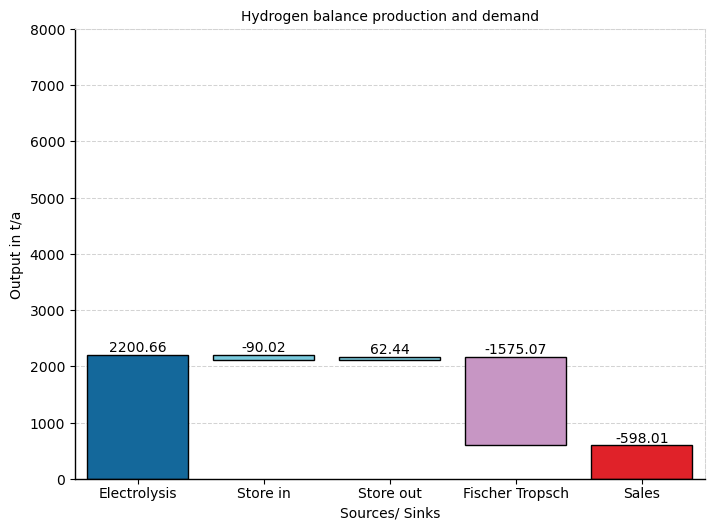

In [41]:
labels = ["Electrolysis","Store in", "Store out", "Fischer Tropsch", "Sales" ]
colors = [col_pem, col_h2s, col_h2s , col_ft, col_sell]
values = [result_pem_flowsum_h2out/1000, -result_h2s_flowsum_in/1000, result_h2s_flowsum_out/1000, -result_ft_flowsum_h2in/1000, -result_h2verkauf_flowsum/1000]

# Berechnungen für das Wasserfalldiagramm
running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))

#ax.axhspan(0, 700, facecolor=col_etc)


bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

# Werte an die Balken hinzufügen (immer oberhalb)
for bar, value in zip(bars, values):
    height = bar.get_height()
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)

ax = plt.gca()
#ax.axvspan(-0.75, 5, facecolor=col_etc, alpha=0.3)    # Rechts
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(min(running_total), max(running_total) + max(running_total)*0.1 )
plt.xlim(-0.5, 4.5 )
plt.ylim(0, 8000 )

plt.title("Hydrogen balance production and demand", fontsize=10)
plt.ylabel("Output in t/a", fontsize=10)
plt.xlabel("Sources/ Sinks")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=0, pad=2)
plt.tick_params(axis='y', labelsize=10, rotation=0)

plt.savefig("Bilder/calc_h2bilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()

## 4.2 Einnahmen und Aussgaben

### 4.2.1 Investitionssummen vor Verzinsung in Euro

In [42]:
calc_gesamtinvest_pem = Eingangsdaten["capex_pem"] * result_pem_leistung                                                                             # kW * €/kW = €
calc_gesamtinvest_wka = Eingangsdaten["capex_wkaon"] * result_wka_leistung                                                                           # kW * €/kW = €
calc_gesamtinvest_pv = Eingangsdaten["capex_pv"] * result_pv_leistung                                                                                # kW * €/kW = €
calc_gesamtinvest_bat = (Eingangsdaten["capex_bat_kapa"] / Eingangsdaten["c_rate_bat"] + Eingangsdaten["capex_bat_leistung"]) * result_bat_leistung  # (€/kWh *h  + €/kW ) *kW = €
calc_gesamtinvest_dac = Eingangsdaten["capex_dac"] * result_dac_leistung / Eingangsdaten["strombedarf_dac"]                                          # €/kg *h *kW * kg/kWh = €
calc_gesamtinvest_h2s = Eingangsdaten["capex_h2s"] * result_h2s_kapa                                                                                 # €/kg * kg = €
calc_gesamtinvest_ft = Eingangsdaten["capex_ft"] * Eingangsdaten["produktionskapa_ft"]                                                               # €/kg * h * kg/h = €
calc_gesamtinvest_hp = Eingangsdaten["capex_hp"] * result_hp_leistung / Eingangsdaten["strombedarf_hp"]                                              # €/kW_th * kW_el * kW_th/kW_el = €
calc_gesamtinvest_qs = Eingangsdaten["capex_qs"] * result_qs_kapa                                                                                    # €/kWh * kWh = €

calc_gesamtinvest = calc_gesamtinvest_pem +calc_gesamtinvest_wka +calc_gesamtinvest_pv +calc_gesamtinvest_bat +calc_gesamtinvest_dac +calc_gesamtinvest_h2s +calc_gesamtinvest_ft +calc_gesamtinvest_hp + calc_gesamtinvest_qs

Ergebnisse_df.loc["calc_gesamtinvest_pem", "Wert"] = calc_gesamtinvest_pem
Ergebnisse_df.loc["calc_gesamtinvest_wka", "Wert"] = calc_gesamtinvest_wka
Ergebnisse_df.loc["calc_gesamtinvest_pv", "Wert"] = calc_gesamtinvest_pv
Ergebnisse_df.loc["calc_gesamtinvest_bat", "Wert"] = calc_gesamtinvest_bat
Ergebnisse_df.loc["calc_gesamtinvest_dac", "Wert"] = calc_gesamtinvest_dac
Ergebnisse_df.loc["calc_gesamtinvest_h2s", "Wert"] = calc_gesamtinvest_h2s
Ergebnisse_df.loc["calc_gesamtinvest_ft", "Wert"] = calc_gesamtinvest_ft
Ergebnisse_df.loc["calc_gesamtinvest_hp", "Wert"] = calc_gesamtinvest_hp
Ergebnisse_df.loc["calc_gesamtinvest_qs", "Wert"] = calc_gesamtinvest_qs

Ergebnisse_df.loc["calc_gesamtinvest", "Wert"] = calc_gesamtinvest


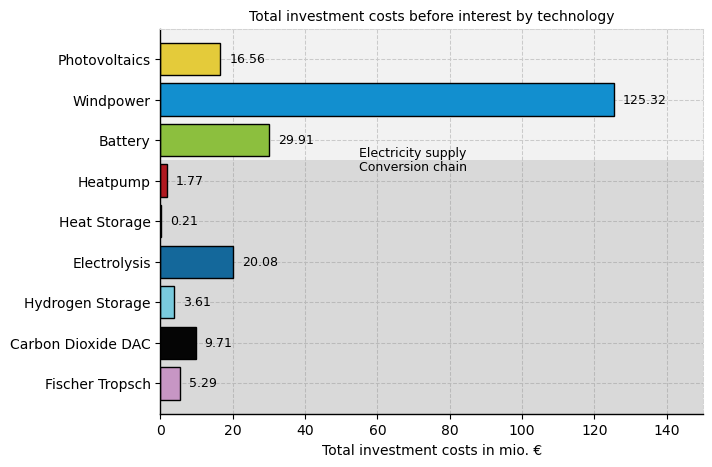

In [43]:
categories = ["Fischer Tropsch", "Carbon Dioxide DAC", "Hydrogen Storage", "Electrolysis", "Heat Storage" ,"Heatpump", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_gesamtinvest_ft / 1e6, calc_gesamtinvest_dac / 1e6, calc_gesamtinvest_h2s / 1e6,
calc_gesamtinvest_pem / 1e6, calc_gesamtinvest_qs/1e6, calc_gesamtinvest_hp/1e6,  calc_gesamtinvest_bat / 1e6, calc_gesamtinvest_wka / 1e6,
calc_gesamtinvest_pv / 1e6
]
colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 5.5
ax.axhspan(cut, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(55, cut-0.25, "Conversion chain", fontsize=9, color="black")  
ax.text(55, cut+0.1, "Electricity supply", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total investment costs in mio. €", fontsize=10)
plt.title("Total investment costs before interest by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 150])

plt.savefig("Bilder/calc_gesamtinvest_bar.png", dpi=300, bbox_inches='tight')

### 4.2.2 Annuitäten in €/a

In [44]:
calc_annuity_pem = result_pem_leistung * annuity_pem                                                                        # kW *  €/kWa = €/a
calc_annuity_wka = result_wka_leistung * annuity_wkaon                                                                      # kW *  €/kWa = €/a
calc_annuity_pv = result_pv_leistung * annuity_pv                                                                           # kW *  €/kWa = €/a
calc_annuity_dac = result_dac_leistung/ Eingangsdaten["strombedarf_dac"] * annuity_dac                                      # kW * kg/kWh €/a * h/kg = €/a
calc_annuity_h2s = result_h2s_kapa * annuity_h2s                                                                            # kg * €/kga * a = €/a
calc_annuity_ft = Eingangsdaten["produktionskapa_ft"] * annuity_ft                                                          # kg/h * €/a * h/kg  = €/a
calc_annuity_bat = (annuity_bat_kapa * result_bat_kapa + annuity_bat_leistung * result_bat_leistung )                       # (€/kWha * kWh ) + (€/kWa * kW ) = €/a
calc_annuity_hp = result_hp_leistung * annuity_hp / Eingangsdaten["strombedarf_hp"]                                         # €/(kW_th * a) * kW_el * kW_th/kW_el = €/a
calc_annuity_qs = result_qs_kapa * annuity_qs                                                                               # kWh * €/kWh a = €/a

calc_annuity_gesamt = calc_annuity_pem + calc_annuity_wka + calc_annuity_pv + calc_annuity_dac + calc_annuity_h2s + calc_annuity_ft + calc_annuity_bat + calc_annuity_hp + calc_annuity_qs


Ergebnisse_df.loc["calc_annuity_pem", "Wert"] = calc_annuity_pem
Ergebnisse_df.loc["calc_annuity_wka", "Wert"] = calc_annuity_wka
Ergebnisse_df.loc["calc_annuity_pv", "Wert"] = calc_annuity_pv
Ergebnisse_df.loc["calc_annuity_dac", "Wert"] = calc_annuity_dac
Ergebnisse_df.loc["calc_annuity_h2s", "Wert"] = calc_annuity_h2s
Ergebnisse_df.loc["calc_annuity_ft", "Wert"] = calc_annuity_ft
Ergebnisse_df.loc["calc_annuity_bat", "Wert"] = calc_annuity_bat
Ergebnisse_df.loc["calc_annuity_hp", "Wert"] = calc_annuity_hp
Ergebnisse_df.loc["calc_annuity_qs", "Wert"] = calc_annuity_qs

Ergebnisse_df.loc["calc_annuity_gesamt", "Wert"] = calc_annuity_gesamt


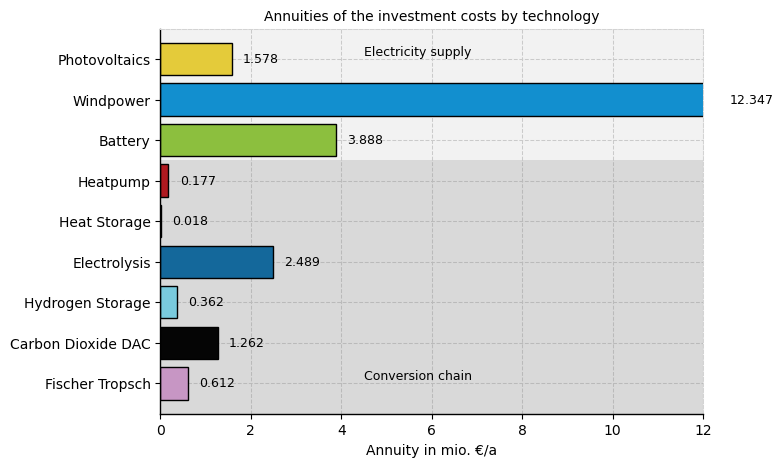

In [45]:
categories = ["Fischer Tropsch", "Carbon Dioxide DAC", "Hydrogen Storage", "Electrolysis", "Heat Storage", "Heatpump", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_annuity_ft / 1e6, calc_annuity_dac / 1e6, calc_annuity_h2s / 1e6,
calc_annuity_pem / 1e6, calc_annuity_qs/1e6, calc_annuity_hp/1e6, calc_annuity_bat / 1e6, calc_annuity_wka / 1e6,
calc_annuity_pv / 1e6
]
colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 5.5
ax.axhspan(cut, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(4.5, 8.1, "Electricity supply", fontsize=9, color="black")  
ax.text(4.5, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.3f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Annuity in mio. €/a", fontsize=10)
plt.title("Annuities of the investment costs by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 12])

plt.savefig("Bilder/calc_annuity_bar.png", dpi=300, bbox_inches='tight')

### 4.2.3 Investitionskosten Verzinst in €

In [46]:
calc_verzinstinvest_pem = calc_annuity_pem * Eingangsdaten["lebensdauer_pem"]                                                       # €/a * a = €
calc_verzinstinvest_wka = calc_annuity_wka * Eingangsdaten["lebensdauer_wkaon"]                                                     # €/a * a = €
calc_verzinstinvest_pv = calc_annuity_pv * Eingangsdaten["lebensdauer_pv"]                                                          # €/a * a = €
calc_verzinstinvest_dac = calc_annuity_dac * Eingangsdaten["lebensdauer_dac"]                                                       # €/a * a = €
calc_verzinstinvest_h2s = calc_annuity_h2s * Eingangsdaten["lebensdauer_h2s"]                                                       # €/a * a = €
calc_verzinstinvest_ft = calc_annuity_ft * Eingangsdaten["lebensdauer_ft"]                                                          # €/a * a = €
calc_verzinstinvest_bat = calc_annuity_bat * Eingangsdaten["lebensdauer_bat"]                                                       # €/a * a = €
calc_verzinstinvest_hp = calc_annuity_hp * Eingangsdaten["lebensdauer_hp"]                                                          # €/a * a = €
calc_verzinstinvest_qs = calc_annuity_qs * Eingangsdaten["lebensdauer_qs"]

calc_verzinstinvest_gesamt = calc_verzinstinvest_pem + calc_verzinstinvest_wka + calc_verzinstinvest_pv + calc_verzinstinvest_dac + calc_verzinstinvest_h2s + calc_verzinstinvest_ft + calc_verzinstinvest_bat + calc_verzinstinvest_hp +calc_verzinstinvest_qs

Ergebnisse_df.loc["calc_verzinstinvest_pem", "Wert"] = calc_verzinstinvest_pem
Ergebnisse_df.loc["calc_verzinstinvest_wka", "Wert"] = calc_verzinstinvest_wka
Ergebnisse_df.loc["calc_verzinstinvest_pv", "Wert"] = calc_verzinstinvest_pv
Ergebnisse_df.loc["calc_verzinstinvest_bat", "Wert"] = calc_verzinstinvest_bat
Ergebnisse_df.loc["calc_verzinstinvest_dac", "Wert"] = calc_verzinstinvest_dac
Ergebnisse_df.loc["calc_verzinstinvest_h2s", "Wert"] = calc_verzinstinvest_h2s
Ergebnisse_df.loc["calc_verzinstinvest_ft", "Wert"] = calc_verzinstinvest_ft
Ergebnisse_df.loc["calc_verzinstinvest_hp", "Wert"] = calc_verzinstinvest_hp
Ergebnisse_df.loc["calc_verzinstinvest_qs", "Wert"] = calc_verzinstinvest_qs

Ergebnisse_df.loc["calc_verzinstinvest_gesamt", "Wert"] = calc_verzinstinvest_gesamt


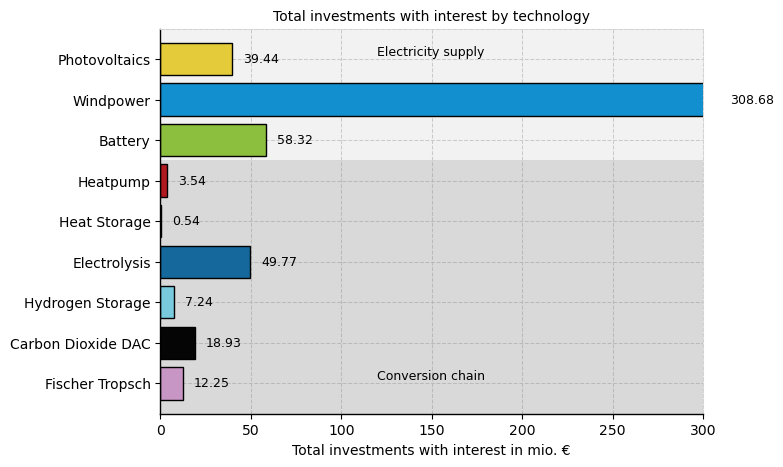

In [47]:
categories = ["Fischer Tropsch", "Carbon Dioxide DAC", "Hydrogen Storage", "Electrolysis","Heat Storage", "Heatpump", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_verzinstinvest_ft / 1e6, calc_verzinstinvest_dac / 1e6, calc_verzinstinvest_h2s / 1e6,
calc_verzinstinvest_pem / 1e6, calc_verzinstinvest_qs/1e6, calc_verzinstinvest_hp/1e6, calc_verzinstinvest_bat / 1e6, calc_verzinstinvest_wka / 1e6,
calc_verzinstinvest_pv / 1e6
]
colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 5.5
ax.axhspan(cut, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(120, 8.1, "Electricity supply", fontsize=9, color="black")  
ax.text(120, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total investments with interest in mio. €", fontsize=10)
plt.title("Total investments with interest by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 300])

plt.savefig("Bilder/calc_verzinstinvest_bar.png", dpi=300, bbox_inches='tight')

### 4.2.4 Einnahmen in €/a

In [48]:
calc_einnahmen_stromverkauf =  result_stromverkauf_flowsum * Eingangsdaten["stromerloes"] *-1
calc_einnahmen_h2verkauf = result_h2verkauf_flowsum * Eingangsdaten["wasserstofferloes"] * -1               # kg/a * €/kg = €/a
calc_einnahmen_safverkauf = result_safverkauf_flowsum * Eingangsdaten["kerosinerloes"] * -1                # kg/a * €/kg = €/a
calc_einnahmen_naphverkauf = result_naphverkauf_flowsum * Eingangsdaten["naphthaerloes"] * -1

calc_einnnahmen_qverkauf =  result_qverkauf_flowsum * Eingangsdaten["waermeerloes"] * -1

Ergebnisse_df.loc["calc_einnahmen_stromverkauf", "Wert"] = calc_einnahmen_stromverkauf
Ergebnisse_df.loc["calc_einnahmen_h2verkauf", "Wert"] = calc_einnahmen_h2verkauf
Ergebnisse_df.loc["calc_einnahmen_safverkauf", "Wert"] = calc_einnahmen_safverkauf
Ergebnisse_df.loc["calc_einnnahmen_qverkauf", "Wert"] = calc_einnnahmen_qverkauf
Ergebnisse_df.loc["calc_einnahmen_naphverkauf", "Wert"] = calc_einnahmen_naphverkauf

### 4.2.5 Betriebskosten OPEX in €/a

In [49]:
calc_strombezug_kosten = result_strombezug_flowsum * Eingangsdaten["strompreis"]                                                              # kWh/a * €/kWh = €/a
calc_opex_fix_wkaon = result_wka_leistung * Eingangsdaten["opex_fix_wkaon"]                                                                   # kW * €/kWa = €/a    
calc_opex_fix_pv = result_pv_leistung * Eingangsdaten["opex_fix_pv"]                                                                          # kW * €/kWa = €/a
calc_opex_fix_bat = result_bat_leistung * Eingangsdaten["opex_fix_bat"] * Eingangsdaten["capex_bat_leistung"]                                 # kW * %/a * €/kW = €/a
calc_opex_fix_pem = result_pem_leistung * Eingangsdaten["opex_pem"] * Eingangsdaten["capex_pem"]                                              # kW * %/a * €/kW = €/a
calc_opex_fix_dac = result_dac_leistung/ Eingangsdaten["strombedarf_dac"] * Eingangsdaten["opex_dac"] * Eingangsdaten["capex_dac"]            # kW * kg/kWh * %/a * (€/kg * h) = €/a
calc_opex_fix_h2s = result_h2s_kapa * Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"]                                                  # kg/h * %/a * €/kg *h = €/a
calc_opex_fix_ft = Eingangsdaten['produktionskapa_ft'] * Eingangsdaten['opex_ft']* Eingangsdaten['capex_ft']                                  # kg/h * %/a * €/kg * h = €/a
calc_opex_var_wkaon = Eingangsdaten["opex_var_wkaon"] * result_wka_flowsum_generation                                                         # €/kWh * kWh/a = €/a
calc_opex_var_pv = Eingangsdaten["opex_var_pv"] * result_pv_flowsum_generation                                                                # €/kWh * kWh/a = €/a
calc_opex_fix_hp = Eingangsdaten["opex_hp"] * Eingangsdaten["capex_hp"] * result_hp_leistung / Eingangsdaten["strombedarf_hp"]  	          # %/a * €/kW_th * kW_el * kW_th/kW_el = €/a
calc_opex_fix_qs = Eingangsdaten["opex_qs"] * Eingangsdaten["capex_qs"] * result_qs_kapa                                                      # %/a * €/kWh * kWh = €/a

calc_opex_gesamt = calc_strombezug_kosten + calc_opex_fix_wkaon + calc_opex_fix_pv + calc_opex_fix_bat + calc_opex_fix_pem + calc_opex_fix_dac + calc_opex_fix_h2s + calc_opex_fix_ft + calc_opex_var_wkaon + calc_opex_var_pv + calc_opex_fix_hp  + calc_opex_fix_qs# €/a


Ergebnisse_df.loc["calc_strombezug_kosten", "Wert"] = calc_strombezug_kosten
Ergebnisse_df.loc["calc_opex_fix_wkaon", "Wert"] = calc_opex_fix_wkaon
Ergebnisse_df.loc["calc_opex_fix_pv", "Wert"] = calc_opex_fix_pv
Ergebnisse_df.loc["calc_opex_fix_bat", "Wert"] = calc_opex_fix_bat
Ergebnisse_df.loc["calc_opex_fix_pem", "Wert"] = calc_opex_fix_pem
Ergebnisse_df.loc["calc_opex_fix_dac", "Wert"] = calc_opex_fix_dac
Ergebnisse_df.loc["calc_opex_fix_h2s", "Wert"] = calc_opex_fix_h2s
Ergebnisse_df.loc["calc_opex_fix_ft", "Wert"] = calc_opex_fix_ft
Ergebnisse_df.loc["calc_opex_var_wkaon", "Wert"] = calc_opex_var_wkaon
Ergebnisse_df.loc["calc_opex_var_pv", "Wert"] = calc_opex_var_pv
Ergebnisse_df.loc["calc_opex_fix_hp", "Wert"] = calc_opex_fix_hp
Ergebnisse_df.loc["calc_opex_fix_qs", "Wert"] = calc_opex_fix_qs

Ergebnisse_df.loc["calc_opex_gesamt", "Wert"] = calc_opex_gesamt


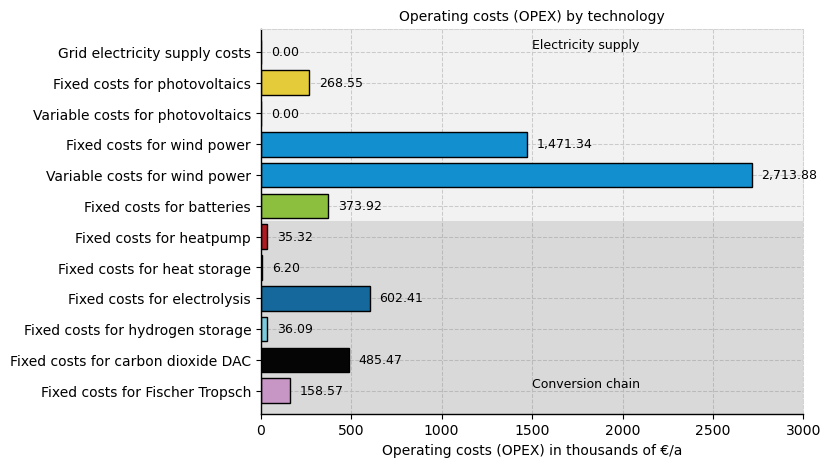

In [50]:

categories = [
"Fixed costs for Fischer Tropsch", "Fixed costs for carbon dioxide DAC", "Fixed costs for hydrogen storage", "Fixed costs for electrolysis", "Fixed costs for heat storage", "Fixed costs for heatpump",
"Fixed costs for batteries", "Variable costs for wind power", "Fixed costs for wind power",
"Variable costs for photovoltaics", "Fixed costs for photovoltaics", "Grid electricity supply costs"
]
values = [
calc_opex_fix_ft / 1e3, calc_opex_fix_dac / 1e3, calc_opex_fix_h2s / 1e3, calc_opex_fix_pem / 1e3,  calc_opex_fix_qs/1e3, calc_opex_fix_hp / 1e3,
calc_opex_fix_bat / 1e3, calc_opex_var_wkaon / 1e3, calc_opex_fix_wkaon / 1e3,
calc_opex_var_pv / 1e3, calc_opex_fix_pv / 1e3, calc_strombezug_kosten / 1e3
]
colors = [col_ft, col_dac, col_h2s, col_pem, col_qs, col_hp, col_bat, col_wka, col_wka, col_pv, col_pv, col_buy]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 5.5
ax.axhspan(cut, 12, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(1500, 11.1, "Electricity supply", fontsize=9, color="black")  
ax.text(1500, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Operating costs (OPEX) in thousands of €/a", fontsize=10)
plt.title("Operating costs (OPEX) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,3000)

plt.savefig("Bilder/calc_opex_bar.png", dpi=300, bbox_inches='tight')

## 4.3 Finanzielle Bilanzierung

### 4.3.1 Gesamtkosten pro Technologie und Jahr

In [51]:
calc_cost_pv = calc_annuity_pv + calc_opex_fix_pv + calc_opex_var_pv                      # €/a
calc_cost_wkaon = calc_annuity_wka + calc_opex_fix_wkaon + calc_opex_var_wkaon       
calc_cost_pem = calc_annuity_pem + calc_opex_fix_pem
calc_cost_ft = calc_annuity_ft + calc_opex_fix_ft
calc_cost_dac = calc_annuity_dac + calc_opex_fix_dac
calc_cost_h2s = calc_annuity_h2s + calc_opex_fix_h2s                                                       
calc_cost_bat = calc_annuity_bat + calc_opex_fix_bat
calc_cost_hp = calc_annuity_hp + calc_opex_fix_hp
calc_cost_qs = calc_annuity_qs + calc_opex_fix_qs 

calc_cost_gesamt = calc_cost_dac + calc_cost_bat + calc_cost_h2s + calc_cost_ft + calc_cost_pem + calc_cost_wkaon + calc_cost_pv + calc_cost_hp + calc_cost_qs + calc_strombezug_kosten

Ergebnisse_df.loc["calc_cost_pv", "Wert"] = calc_cost_pv
Ergebnisse_df.loc["calc_cost_wkaon", "Wert"] = calc_cost_wkaon
Ergebnisse_df.loc["calc_cost_pem", "Wert"] = calc_cost_pem
Ergebnisse_df.loc["calc_cost_ft", "Wert"] = calc_cost_ft
Ergebnisse_df.loc["calc_cost_dac", "Wert"] = calc_cost_dac
Ergebnisse_df.loc["calc_cost_h2s", "Wert"] = calc_cost_h2s
Ergebnisse_df.loc["calc_cost_bat", "Wert"] = calc_cost_bat
Ergebnisse_df.loc["calc_cost_hp", "Wert"] = calc_cost_hp
Ergebnisse_df.loc["calc_cost_qs", "Wert"] = calc_cost_qs

Ergebnisse_df.loc["calc_cost_gesamt", "Wert"] = calc_cost_gesamt


### 4.3.2 Berechnung Bilanz

In [52]:
calc_einnahmen_gesamt = calc_einnahmen_h2verkauf + calc_einnahmen_safverkauf +  calc_einnahmen_stromverkauf + calc_einnnahmen_qverkauf + calc_einnahmen_naphverkauf

calc_ausgaben_gesamt = calc_opex_gesamt + calc_annuity_gesamt

calc_GuV = calc_einnahmen_gesamt - calc_ausgaben_gesamt

Ergebnisse_df.loc["calc_einnahmen_gesamt", "Wert"] = calc_einnahmen_gesamt
Ergebnisse_df.loc["calc_ausgaben_gesamt", "Wert"] = calc_ausgaben_gesamt
Ergebnisse_df.loc["calc_GuV", "Wert"] = calc_GuV

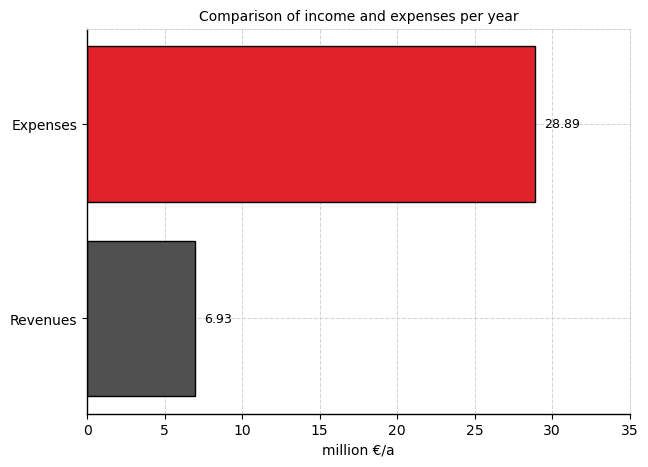

In [53]:
categories = ["Revenues", "Expenses"]
values = [calc_einnahmen_gesamt/1000000, calc_ausgaben_gesamt/1000000]
colors = [col_buy, col_sell]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("million €/a", fontsize=10)
plt.title("Comparison of income and expenses per year", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,35)

plt.savefig("Bilder/calc_eurobilanz_bar.png", dpi=300, bbox_inches='tight')

### 4.3.3 Bilanz Einzelposten

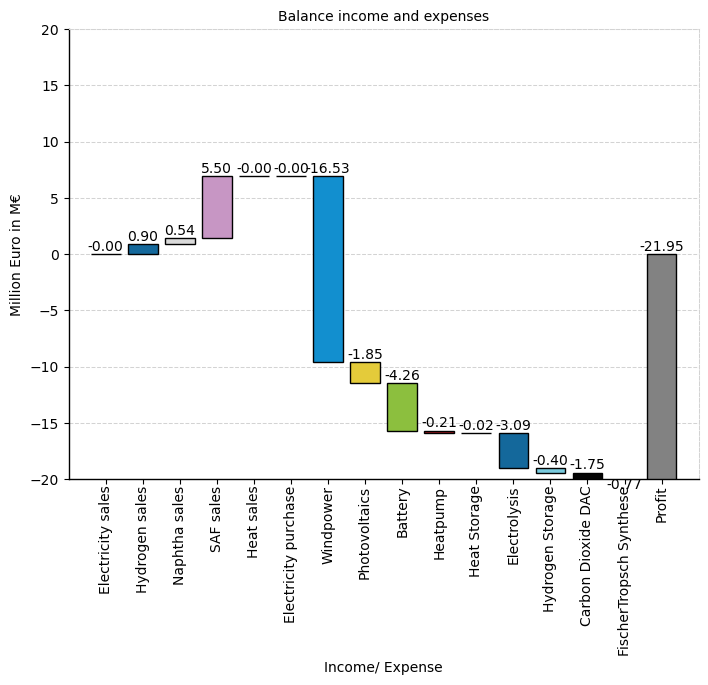

In [54]:
labels = ['Electricity sales', 'Hydrogen sales', 'Naphtha sales', 'SAF sales', 'Heat sales' ,'Electricity purchase', 'Windpower', 'Photovoltaics','Battery', "Heatpump" ,'Heat Storage', 'Electrolysis','Hydrogen Storage', 'Carbon Dioxide DAC',  'FischerTropsch Synthese', 'Profit']
colors = [col_sell, col_h2, col_naph, col_saf, col_q, col_buy, col_wka, col_pv, col_bat,col_hp, col_qs, col_pem, col_h2s, col_dac, col_ft, col_etc]


values = [calc_einnahmen_stromverkauf/1e6,
            calc_einnahmen_h2verkauf/1e6,
            calc_einnahmen_naphverkauf/1e6,
            calc_einnahmen_safverkauf/1e6,
            calc_einnnahmen_qverkauf/1e6,
            - calc_strombezug_kosten/1e6,
            - calc_cost_wkaon/1e6,
            - calc_cost_pv/1e6,
            - calc_cost_bat/1e6,
            - calc_cost_hp/1e6,
            - calc_cost_qs/1e6,
            - calc_cost_pem/1e6,
            - calc_cost_h2s/1e6,
            - calc_cost_dac/1e6,
            - calc_cost_ft/1e6,
            - calc_GuV/1e6
            ]


running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

for bar, value, label in zip(bars, values, labels):
    height = bar.get_height()
    #display_value = abs(value) if label == "Profit" else value  # Gewinn als positiv anzeigen
    display_value = -abs(value) if label == "Profit" else value
    #display_value = value
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 0.05, f'{display_value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 0.05, f'{display_value:.2f}', 
                 ha='center', va='bottom', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True) 

plt.ylim(-20, 20)
plt.xlim(-1, 16)

plt.title("Balance income and expenses", fontsize=10)
plt.ylabel("Million Euro in M€", fontsize=10)
plt.xlabel("Income/ Expense")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=90, pad=1)
plt.tick_params(axis='y', labelsize=10, rotation=0)

plt.savefig("Bilder/calc_EuroBilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()


## 4.4 Gestehungskosten

### 4.4.1 Levelized Cost of Wind and PV

In [55]:
calc_ucrf_wka = (Eingangsdaten["zinssatz_wkaon"]*(1+Eingangsdaten["zinssatz_wkaon"])**Eingangsdaten["lebensdauer_wkaon"])/((1+Eingangsdaten["zinssatz_wkaon"])**Eingangsdaten["lebensdauer_wkaon"]-1)
if result_wka_flowsum_generation >0:
    calc_lcoe_wka = (calc_gesamtinvest_wka * calc_ucrf_wka + calc_opex_fix_wkaon)/result_wka_flowsum_generation + Eingangsdaten["opex_var_wkaon"]                                                               # (€ * %/a + €/a) * a/kWh + €/kWh = €/KWh
else: calc_lcoe_wka = 0
print("Levelized Cost of Electricity (Wind): ", f"{calc_lcoe_wka*100:.2f}", "ct/kWh")                                                                                                                       # Die Stromgestehungskosten von Onshore-Windenergieanlagen(WEA) liegen im Jahr 2024 zwischen 4,3 und 9,2 €Cent/kWh
Ergebnisse_df.loc["calc_lcoe_wka", "Wert"] = calc_lcoe_wka*100

Levelized Cost of Electricity (Wind):  3.05 ct/kWh


In [56]:
calc_ucrf_pv = (Eingangsdaten["zinssatz_pv"]*(1+Eingangsdaten["zinssatz_pv"])**Eingangsdaten["lebensdauer_pv"])/((1+Eingangsdaten["zinssatz_pv"])**Eingangsdaten["lebensdauer_pv"]-1)
if result_pv_flowsum_generation >0:
    calc_lcoe_pv = (calc_gesamtinvest_pv * calc_ucrf_pv + calc_opex_fix_pv)/result_pv_flowsum_generation + Eingangsdaten["opex_var_pv"]                                                               # (€ * %/a + €/a) * a/kWh + €/kWh = €/KWh
else: calc_lcoe_pv = 0
print("Levelized Cost of Electricity (PV): ", f"{calc_lcoe_pv*100:.2f}", "ct/kWh")                                                                                                                # Stromgestehungskosten von PV-Anlagen je nach Anlagentyp und Sonneneinstrahlung zwischen 4,1 und 14,4 €Cent/kWh variieren
Ergebnisse_df.loc["calc_lcoe_pv", "Wert"] = calc_lcoe_pv*100

Levelized Cost of Electricity (PV):  6.99 ct/kWh


### 4.4.2 Levelized Cost of Battery

In [57]:
calc_ucrf_bat = (Eingangsdaten["zinssatz_bat"]*(1+Eingangsdaten["zinssatz_bat"])**Eingangsdaten["lebensdauer_bat"])/((1+Eingangsdaten["zinssatz_bat"])**Eingangsdaten["lebensdauer_bat"]-1)
if result_bat_flowsum_out >0:
    calc_lcoe_bat = (calc_gesamtinvest_bat * calc_ucrf_bat + calc_opex_fix_bat)/result_bat_flowsum_out      # (€ * %/a + €/a) * a/kWh  = €/kWh
else: calc_lcoe_bat=0.0
print("Levelized Cost of Battery: ", f"{calc_lcoe_bat*100:.2f}", "ct/kWh to store")                                               
Ergebnisse_df.loc["calc_lcoe_bat", "Wert"] = calc_lcoe_bat*100

Levelized Cost of Battery:  12.98 ct/kWh to store


### 4.4.3 Levelized Cost of Electricity


In [58]:
if (result_wka_flowsum_generation +result_pv_flowsum_generation -result_stromverkauf_flowsum -result_bat_flowsum_in +result_bat_flowsum_out +result_strombezug_flowsum) >0:
    
    calc_lcoe_mix = ((result_pv_flowsum_generation * calc_lcoe_pv) + (result_wka_flowsum_generation*calc_lcoe_wka) +(result_stromverkauf_flowsum * Eingangsdaten["stromerloes"]) + (calc_gesamtinvest_bat * calc_ucrf_bat + calc_opex_fix_bat) + (Eingangsdaten["strompreis"]*result_strombezug_flowsum))/(result_wka_flowsum_generation +result_pv_flowsum_generation -result_stromverkauf_flowsum -result_bat_flowsum_in +result_bat_flowsum_out +result_strombezug_flowsum)

else:
    calc_lcoe_mix = 0

print("gewichteter Durchschnitt der Levelized Cost of Electricity inkl Batterie und Einkauf: ", f"{calc_lcoe_mix*100:.2f}", "ct/kWh")
Ergebnisse_df.loc["calc_lcoe_mix", "Wert"] = calc_lcoe_mix*100

gewichteter Durchschnitt der Levelized Cost of Electricity inkl Batterie und Einkauf:  10.32 ct/kWh


### 4.4.4 Levelized Cost of Hydrogen Storage

In [59]:
calc_ucrf_h2s = (Eingangsdaten["zinssatz_h2s"]*(1+Eingangsdaten["zinssatz_h2s"])**Eingangsdaten["lebensdauer_h2s"])/((1+Eingangsdaten["zinssatz_h2s"])**Eingangsdaten["lebensdauer_h2s"]-1)
if result_h2s_flowsum_out >0:
    calc_lcoh_h2s = (calc_gesamtinvest_h2s * calc_ucrf_h2s + calc_opex_fix_h2s)/result_h2s_flowsum_out                                                           # (€ * %/a + €/a) * a/kg = €/kg
else:
    calc_lcoh_h2s = 0
print("Levelized Cost of Hydrogen Storage: ", f"{calc_lcoh_h2s:.2f}", "€/kg")
Ergebnisse_df.loc["calc_lcoh_h2s", "Wert"] = calc_lcoh_h2s                                                                                                                       

Levelized Cost of Hydrogen Storage:  6.38 €/kg


### 4.4.5 Levelized Cost of Electrolysis

In [60]:
calc_ucrf_pem = (Eingangsdaten["zinssatz_pem"]*(1+Eingangsdaten["zinssatz_pem"])**Eingangsdaten["lebensdauer_pem"])/((1+Eingangsdaten["zinssatz_pem"])**Eingangsdaten["lebensdauer_pem"]-1)

if result_pem_flowsum_h2out > 0:
    #               (€                      * %/a           + €/a)             + (€/kWh        *kWh/a)                    * a/kg 
    calc_lcoh_pem = (calc_gesamtinvest_pem * calc_ucrf_pem + calc_opex_fix_pem + (calc_lcoe_mix*result_pem_flowsum_elin))/result_pem_flowsum_h2out                          
else:
    calc_lcoh_pem = 0
print("Levelized Cost of Electrolysis (PEM): ", f"{calc_lcoh_pem:.2f}", "€/kg")                                                                                                                                      # Zwischen 1.30€/kg und 3.80€/kg laut: (https://www.iea.org/data-and-statistics/data-tools/levelised-cost-of-hydrogen-maps)
Ergebnisse_df.loc["calc_lcoh_pem", "Wert"] = calc_lcoh_pem

Levelized Cost of Electrolysis (PEM):  6.57 €/kg


### 4.4.5 Levelized Cost of Hydrogen

In [61]:
if (result_pem_flowsum_h2out-result_h2verkauf_flowsum-result_h2s_flowsum_in+result_h2s_flowsum_out) >0:
    
    calc_lcoh_h2 = ((calc_gesamtinvest_pem * calc_ucrf_pem + calc_opex_fix_pem + (calc_lcoe_mix*result_pem_flowsum_elin)) +(result_h2verkauf_flowsum*Eingangsdaten["wasserstofferloes"]) +(calc_gesamtinvest_h2s * calc_ucrf_h2s + calc_opex_fix_h2s))/(result_pem_flowsum_h2out-result_h2verkauf_flowsum-result_h2s_flowsum_in+result_h2s_flowsum_out)
    
else: 
    calc_lcoh_h2 = 0
print("Levelized Cost of Hydrogen: ", f"{calc_lcoh_h2:.2f}", "€/kg")                                                                                                                                      # Zwischen 1.30€/kg und 3.80€/kg laut: (https://www.iea.org/data-and-statistics/data-tools/levelised-cost-of-hydrogen-maps)
Ergebnisse_df.loc["calc_lcoh_h2", "Wert"] = calc_lcoh_h2

Levelized Cost of Hydrogen:  8.86 €/kg


### 4.4.6 Levelized Cost of Heat Storage

In [62]:
calc_ucrf_qs = (Eingangsdaten["zinssatz_qs"]*(1+Eingangsdaten["zinssatz_qs"])**Eingangsdaten["lebensdauer_qs"])/((1+Eingangsdaten["zinssatz_qs"])**Eingangsdaten["lebensdauer_qs"]-1)

if result_qs_flowsum_out >0:
    
    calc_lcoh_qs = (calc_gesamtinvest_qs * calc_ucrf_qs + calc_opex_fix_qs)/result_qs_flowsum_out                                                           

else:
    calc_lcoh_qs =0

print("Levelized Cost of Heat Storage: ", f"{calc_lcoh_qs*100:.2f}", "ct/kWh thermal")
Ergebnisse_df.loc["calc_lcoh_qs", "Wert"] = calc_lcoh_qs*100 

Levelized Cost of Heat Storage:  3.86 ct/kWh thermal


### 4.4.7 Levelized Cost of Heatpump

In [63]:
calc_ucrf_hp = (Eingangsdaten["zinssatz_hp"]*(1+Eingangsdaten["zinssatz_hp"])**Eingangsdaten["lebensdauer_hp"])/((1+Eingangsdaten["zinssatz_hp"])**Eingangsdaten["lebensdauer_hp"]-1)

if result_hp_flowsum_qout >0:
    
    calc_lcoh_hp = ((calc_gesamtinvest_hp * calc_ucrf_hp + calc_opex_fix_hp) + (calc_lcoe_mix * result_hp_flowsum_elin))/result_hp_flowsum_qout                                                            # (€ * %/a + €/a) * a/kg + €/kWh*kWh/kg = €/kg

else:
    calc_lcoh_hp=0
    
print("Levelized Cost of Heat (Heatpump): ", f"{calc_lcoh_hp*100:.2f}", "ct/kWh thermal")                                                                                                                                      # Zwischen 1.30€/kg und 3.80€/kg laut: (https://www.iea.org/data-and-statistics/data-tools/levelised-cost-of-hydrogen-maps)
Ergebnisse_df.loc["calc_lcoh_hp", "Wert"] = calc_lcoh_hp*100

Levelized Cost of Heat (Heatpump):  3.78 ct/kWh thermal


### 4.4.8 Levelized Cost of Heat

In [64]:
if (result_hp_flowsum_qout-result_qverkauf_flowsum-result_qs_flowsum_in+result_qs_flowsum_out) >0:
    
    calc_lcoh_q = ((calc_gesamtinvest_hp * calc_ucrf_hp + calc_opex_fix_hp) + (calc_lcoe_mix * result_hp_flowsum_elin) + (calc_gesamtinvest_qs * calc_ucrf_qs + calc_opex_fix_qs))/(result_hp_flowsum_qout-result_qverkauf_flowsum-result_qs_flowsum_in+result_qs_flowsum_out)
    
else:
    calc_lcoh_q =0
    

print("Levelized Cost of Heat: ", f"{calc_lcoh_q*100:.2f}", "ct/kWh thermal")                                                                                                                                      
Ergebnisse_df.loc["calc_lcoh_q", "Wert"] = calc_lcoh_q*100

Levelized Cost of Heat:  3.92 ct/kWh thermal


### 4.4.9 Levelized Cost of Carbon dioxid

In [65]:
calc_ucrf_dac = (Eingangsdaten["zinssatz_dac"]*(1+Eingangsdaten["zinssatz_dac"])**Eingangsdaten["lebensdauer_dac"])/((1+Eingangsdaten["zinssatz_dac"])**Eingangsdaten["lebensdauer_dac"]-1)

if result_dac_flowsum_co2out>0:
    
    calc_lcon_dac = ((calc_gesamtinvest_dac * calc_ucrf_dac + calc_opex_fix_dac) + (result_dac_flowsum_qin*calc_lcoh_q) +(result_dac_flowsum_elin*calc_lcoe_mix) )/result_dac_flowsum_co2out 

else:
    calc_lcon_dac =0
    
print("Levelized Cost of Carbon dioxid (MEA): ", f"{calc_lcon_dac:.2f}", "€/kg")             
Ergebnisse_df.loc["calc_lcon_mea", "Wert"] = calc_lcon_dac                                                                                                                             

Levelized Cost of Carbon dioxid (MEA):  0.26 €/kg


### 4.4.10 Levelized Cost of Naphtha

In [66]:
calc_ucrf_ft = (Eingangsdaten["zinssatz_ft"]*(1+Eingangsdaten["zinssatz_ft"])**Eingangsdaten["lebensdauer_ft"])/((1+Eingangsdaten["zinssatz_ft"])**Eingangsdaten["lebensdauer_ft"]-1)

if result_ft_flowsum_naphout >0:
    
    calc_lcof_naph = ((calc_gesamtinvest_ft * calc_ucrf_ft + calc_opex_fix_ft) + (result_ft_flowsum_elin*calc_lcoe_mix) + (result_ft_flowsum_h2in*calc_lcoh_h2) + (result_ft_flowsum_co2in*calc_lcon_dac))/result_ft_flowsum_naphout       # (€ * %/a + €/a) * a/kg + €/kWh*kWh/kg +€/kgH2*kgH2/kg + €/CO2 * kgCO2/kg +  = €/kg
else:
    calc_lcof_naph =0
    
print("Levelized Cost of Naphtha (Fischer Tropsch): ", f"{calc_lcof_naph*1000:.2f}", "€/t")          
Ergebnisse_df.loc["calc_lcof_naph", "Wert"] = calc_lcof_naph*1000

Levelized Cost of Naphtha (Fischer Tropsch):  28704.62 €/t


### 4.4.11 Levelized Cost of SAF

In [67]:
if result_ft_flowsum_safout >0:
    
    calc_lcof_saf = ((calc_gesamtinvest_ft * calc_ucrf_ft + calc_opex_fix_ft) + (result_ft_flowsum_elin*calc_lcoe_mix) + (result_ft_flowsum_h2in*calc_lcoh_h2) + (result_ft_flowsum_co2in*calc_lcon_dac))/result_ft_flowsum_safout

else:
    calc_lcof_saf = 0
    
print("Levelized Cost of SAF (Fischer Tropsch): ", f"{calc_lcof_saf*1000:.2f}", "€/t")          
Ergebnisse_df.loc["calc_lcof_saf", "Wert"] = calc_lcof_saf*1000

Levelized Cost of SAF (Fischer Tropsch):  11194.80 €/t


### 4.4.12 Levelized Cost of FT

In [68]:
if (result_ft_flowsum_safout + result_ft_flowsum_naphout) >0:
    
    calc_lcof_ft = ((calc_gesamtinvest_ft * calc_ucrf_ft + calc_opex_fix_ft) + (result_ft_flowsum_elin*calc_lcoe_mix) + (result_ft_flowsum_h2in*calc_lcoh_h2) + (result_ft_flowsum_co2in*calc_lcon_dac))/(result_ft_flowsum_safout + result_ft_flowsum_naphout)

else:
    calc_lcof_ft =0
    
print("Levelized Cost of Fischer Tropsch (SAF+Naphtha): ", f"{calc_lcof_ft*1000:.2f}", "€/t")          
Ergebnisse_df.loc["calc_lcof_ft", "Wert"] = calc_lcof_ft*1000

Levelized Cost of Fischer Tropsch (SAF+Naphtha):  8053.81 €/t


### 4.4.7 Darstellung LCO

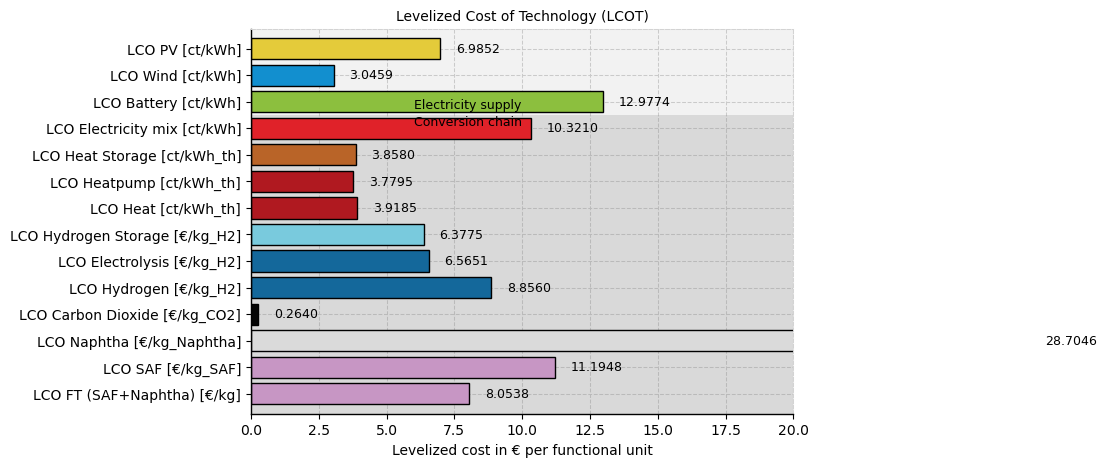

In [69]:
categories = ["LCO FT (SAF+Naphtha) [€/kg]", "LCO SAF [€/kg_SAF]", "LCO Naphtha [€/kg_Naphtha]", "LCO Carbon Dioxide [€/kg_CO2]", "LCO Hydrogen [€/kg_H2]", "LCO Electrolysis [€/kg_H2]", "LCO Hydrogen Storage [€/kg_H2]", "LCO Heat [ct/kWh_th]" , "LCO Heatpump [ct/kWh_th]", "LCO Heat Storage [ct/kWh_th]","LCO Electricity mix [ct/kWh]", "LCO Battery [ct/kWh]", "LCO Wind [ct/kWh]","LCO PV [ct/kWh]", ]
values = [calc_lcof_ft, calc_lcof_saf, calc_lcof_naph, calc_lcon_dac, calc_lcoh_h2, calc_lcoh_pem, calc_lcoh_h2s, calc_lcoh_q*100, calc_lcoh_hp*100, calc_lcoh_qs*100, calc_lcoe_mix*100, calc_lcoe_bat*100, calc_lcoe_wka*100, calc_lcoe_pv*100]
colors = [col_saf, col_saf, col_naph, col_co2, col_h2, col_pem, col_h2s, col_q, col_hp, col_qs, col_el, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 10.5
ax.axhspan(cut, 16, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(6, 10.75, "Electricity supply", fontsize=9, color="black")  
ax.text(6, 10.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.4f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Levelized cost in € per functional unit", fontsize=10)
plt.title("Levelized Cost of Technology (LCOT)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,20)

plt.savefig("Bilder/calc_lcot_bar.png", dpi=300, bbox_inches='tight')

## 4.5 Gesamtkosten je Energieträger

### 4.5.1 Gesamtkosten je kWh

In [70]:
if (result_pem_flowsum_elin+result_ft_flowsum_elin+result_dac_flowsum_elin+result_hp_flowsum_elin) >0:
    calc_cost_el = (calc_cost_pv + calc_cost_wkaon + calc_cost_bat + calc_strombezug_kosten - calc_einnahmen_stromverkauf)/(result_pem_flowsum_elin+result_ft_flowsum_elin+result_dac_flowsum_elin+result_hp_flowsum_elin)
else:
    calc_cost_el = 0
print("Gesamtkosten pro kWh Strom: ", f"{calc_cost_el*100:.2f}", "ct/kWh") 
Ergebnisse_df.loc["calc_cost_el", "Wert"] = calc_cost_el*100

Gesamtkosten pro kWh Strom:  10.32 ct/kWh


### 4.5.2 Gesamtkosten je kg H2

In [71]:
if result_ft_flowsum_h2in >0:
    
    calc_cost_h2 = (calc_cost_pem + calc_cost_h2s + calc_cost_el * result_pem_flowsum_elin - calc_einnahmen_h2verkauf)/result_ft_flowsum_h2in
    
else:
    calc_cost_h2 = 0
print("Gesamtkosten pro kg Wasserstoff: ", f"{calc_cost_h2:.2f}", "€/kg") 
Ergebnisse_df.loc["calc_cost_h2", "Wert"] = calc_cost_h2

Gesamtkosten pro kg Wasserstoff:  8.86 €/kg


### 4.5.3 Gesamtkosten je kWh thermisch

In [72]:
if result_dac_flowsum_qin > 0:
    
    calc_cost_q = (calc_cost_hp + calc_cost_qs + calc_cost_el * result_hp_flowsum_elin - calc_einnnahmen_qverkauf)/result_dac_flowsum_qin

else:
    calc_cost_q = 0
    
print("Gesamtkosten pro kWh Wärme: ", f"{calc_cost_q*100:.2f}", "ct/kWh") 
Ergebnisse_df.loc["calc_cost_q", "Wert"] = calc_cost_q*100

Gesamtkosten pro kWh Wärme:  3.92 ct/kWh


### 4.5.3 Gesamtkosten je kg CO2

In [73]:
if result_ft_flowsum_co2in>0:
    
    calc_cost_co2 = (calc_cost_dac + calc_cost_el * result_dac_flowsum_elin + calc_cost_q * result_dac_flowsum_qin)/result_ft_flowsum_co2in

else:
    calc_cost_co2=0
    
print("Gesamtkosten pro kg Karbondioxid: ", f"{calc_cost_co2:.2f}", "€/kg") 
Ergebnisse_df.loc["calc_cost_co2", "Wert"] = calc_cost_co2

Gesamtkosten pro kg Karbondioxid:  0.26 €/kg


### 4.5.4 Gesamtkosten je kg SAF

In [74]:
if result_safverkauf_flowsum>0:
    
    calc_cost_saf = (calc_cost_ft + calc_cost_el * result_ft_flowsum_elin + calc_cost_co2 * result_ft_flowsum_co2in +  calc_cost_h2 * result_ft_flowsum_h2in)/result_safverkauf_flowsum

else:
    calc_cost_saf =0
    
print("Gesamtkosten pro t SAF: ", f"{calc_cost_saf*1000:.2f}", "€/t") 
Ergebnisse_df.loc["calc_cost_saf", "Wert"] = calc_cost_saf*1000

Gesamtkosten pro t SAF:  11194.80 €/t


### 4.5.5 Gesamtkosten je kg Naphtha

In [75]:
if result_ft_flowsum_naphout >0:
    
    calc_cost_naph = (calc_cost_ft + calc_cost_el * result_ft_flowsum_elin + calc_cost_co2 * result_ft_flowsum_co2in +  calc_cost_h2 * result_ft_flowsum_h2in)/result_ft_flowsum_naphout

else:
    calc_cost_naph =0
    
print("Gesamtkosten pro t Naphtha: ", f"{calc_cost_naph*1000:.2f}", "€/t") 
Ergebnisse_df.loc["calc_cost_naph", "Wert"] = calc_cost_naph*1000

Gesamtkosten pro t Naphtha:  28704.62 €/t


### 4.5.5 Gesamtkosten je Energieträger Darstellung

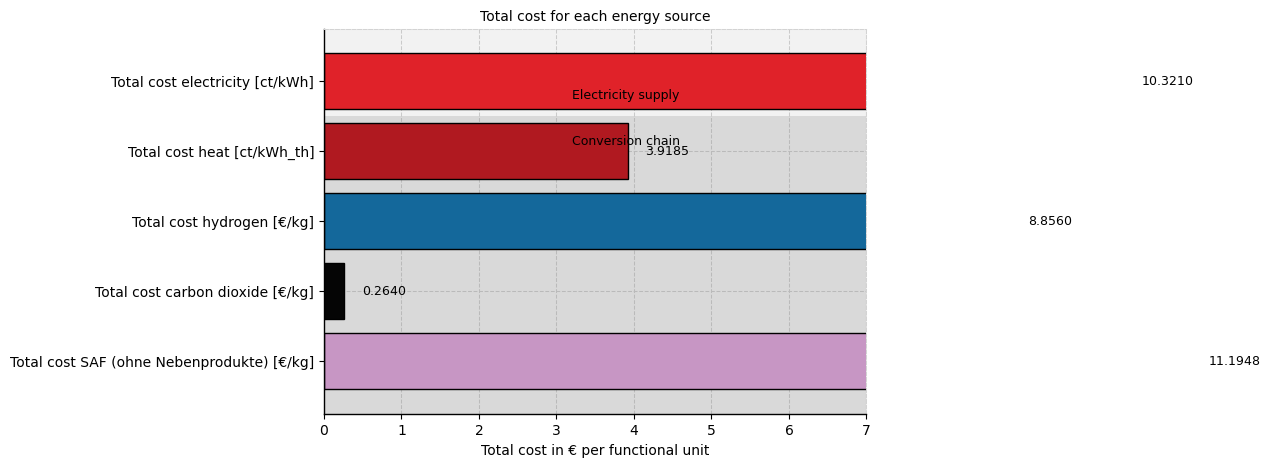

In [76]:
categories = ["Total cost SAF (ohne Nebenprodukte) [€/kg]", "Total cost carbon dioxide [€/kg]", "Total cost hydrogen [€/kg]", "Total cost heat [ct/kWh_th]", "Total cost electricity [ct/kWh]"]
values = [calc_cost_saf, calc_cost_co2, calc_cost_h2, calc_cost_q*100, calc_cost_el*100]
colors = [col_saf, col_co2, col_h2, col_q, col_el]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 6, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(3.2, 3.75, "Electricity supply", fontsize=9, color="black")  
ax.text(3.2, 3.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.4f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total cost in € per functional unit", fontsize=10)
plt.title("Total cost for each energy source", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,7)

plt.savefig("Bilder/calc_cost_source_bar.png", dpi=300, bbox_inches='tight')

## 4.6 Verkaufspreise

In [77]:
calc_maxprice = calc_ausgaben_gesamt/result_safverkauf_flowsum                          # €/a * a/kg_CH3OH = €/kg_CH3OH
print("Maximaler Verkaufspreis zur Bilanznull: ", calc_maxprice.round(2), "€/kg_CH3OH")
Ergebnisse_df.loc["calc_maxprice", "Wert"] = calc_maxprice

Maximaler Verkaufspreis zur Bilanznull:  11.55 €/kg_CH3OH


In [78]:
calc_price = (calc_ausgaben_gesamt - calc_einnahmen_stromverkauf - calc_einnnahmen_qverkauf - calc_einnahmen_h2verkauf)/result_safverkauf_flowsum                          # €/a * a/kg_CH3OH = €/kg_CH3OH
print("Verkaufspreis bei angenommenem Vorverkauf: ", calc_price.round(4), "€/kg_CH3OH")
Ergebnisse_df.loc["calc_price", "Wert"] = calc_price

Verkaufspreis bei angenommenem Vorverkauf:  11.1948 €/kg_CH3OH


# Export der Ergebnisse

In [79]:
Ergebnisse_df = Ergebnisse_df.reset_index()
Ergebnisse_df = Ergebnisse_df[["Kategorie", "Technologie", "Beschreibung", "Variable", "Wert", "Einheit"]]
Ergebnisse_df["Wert"] = Ergebnisse_df["Wert"].round(6)
Ergebnisse_df.to_csv("Ergebnisse.csv", sep=";", encoding="utf-8-sig", decimal=',', index=False)